# Thesis figures: Results chapter and Appendix

Every figure of chapter 6 and the appendix, one section per figure. The `lisathesis` style, Okabe–Ito colours.

In [155]:

import os
import sys
from pathlib import Path

# package root = the folder that contains run_aum.py (works with cwd = package root or evaluation/)
IN_REPO = next(d for d in (Path.cwd(), *Path.cwd().parents) if (d / "run_aum.py").is_file())
for _p in (IN_REPO, IN_REPO / "evaluation"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))
IN_DATA = IN_REPO / "baselines_data" / "data"

# no-LO 8-epoch run
IN_NOLO_RUN_DIR    = IN_DATA / "glare" / "19-08-26_21:11_ep-8_single-gpu"
IN_NOLO_CSV        = IN_NOLO_RUN_DIR / "results" / "mislabels_list_20260819_211102.csv"
IN_NOLO_GRAD_NORMS = IN_NOLO_RUN_DIR / "results" / "grad_norms_20260819_211102.pkl"
IN_NOLO_WEIGHTS    = IN_DATA / "runs" / "test_glare_20072026_0111" / "weights"   # not shipped; only named, no figure reads it

# LO 8-epoch run = GLARE on label_override_8ep_23092026_2135
IN_LO_GLARE_DIR      = IN_DATA / "glare" / "26-09-26_07:42_ep-8_single-gpu"
IN_LO_CSV            = IN_LO_GLARE_DIR / "mislabels_list_20260926_074211.csv"
IN_LO_GRAD_NORMS     = IN_LO_GLARE_DIR / "grad_norms_20260926_074211.pkl"
IN_LO_SPEC           = IN_DATA / "runs" / "label_override_8ep_23092026_2135" / "spec.json"
IN_LO_BASELINES_XLSX = (IN_DATA / "glare" / "label_override_8ep_23092026_2135_baselines" / "evaluation"
                        / "evaluation_20260928_232325.xlsx")   # md5 e353f3b7...

# ground truth + filter sheet (repo)
IN_GT_XLSX        = IN_REPO / "evaluation" / "gt_mislabels_complete.xlsx"              # no-LO runs, 109 rows
IN_GT_LO_XLSX     = IN_REPO / "evaluation" / "gt_mislabels_complete_LO_evalbranch.xlsx"
IN_GT_DERIVED_CSV = IN_REPO / "evaluation" / "gt_mislabels_derived.csv"
IN_OLD_GT_XLSX    = IN_REPO / "evaluation" / "A_CT_ANOMALY_LABELv9.xlsx"
IN_FILTER_XLSX    = IN_REPO / "data" / "data_filter_joined.xlsx"

# CT crops (.npz, <dsname>/<split>/segment0.8mm_vert<N>_sub-<pid>.npz) -- NOT shipped, only the example-image figures read them
IN_CT_DIR = Path(os.environ.get("MISLABELDET_DATASET_DIR", "/home/student/lisa_ma/prepared"))

# output
import matplotlib as mpl
import plotstyle                      # evaluation/plotstyle.py + evaluation/lisathesis.mplstyle
plotstyle.use()
OUT_FIG_DIR = IN_REPO / "figures"
plotstyle.FIG_DIR = OUT_FIG_DIR       # plotstyle.savefig writes here too
PCT = r"\%" if mpl.rcParams["text.usetex"] else "%"   # a literal % inside plot labels
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)
_FIGS_BEFORE = {p.name: p.stat().st_mtime_ns for p in OUT_FIG_DIR.glob("*.pdf")}   # checked in the last cell

_missing = [k for k, v in dict(globals()).items() if k.startswith("IN_") and isinstance(v, Path) and not v.exists()
            and k not in ("IN_NOLO_WEIGHTS", "IN_CT_DIR")]
assert not _missing, f"missing inputs: {_missing}"

/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


#### Setup A: no-LO run (`evaluation_ep8_noLO.ipynb`)

In [156]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [157]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, f1_score

MISLABELS_CSV = IN_NOLO_CSV
RC_XLSX       = IN_GT_XLSX
MAX_SCORE     = 8

FIGURES_DIR = OUT_FIG_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

scores_df = pd.read_csv(MISLABELS_CSV, dtype=str, keep_default_na=False)
scores_df["glare_score"] = pd.to_numeric(scores_df["glare score"], errors="coerce")
scores_df = scores_df.dropna(subset=["glare_score"]).reset_index(drop=True)


In [158]:
# To get the mislabeled / clean label
df_rc     = pd.read_excel(RC_XLSX)                           # kein sheet_name nötig
positives = set(df_rc["sample_id"].astype(str))             # sample_id statt id, kein in_training_data Filter
scores_df["mislabeled"] = scores_df["id"].apply(lambda x: 1 if x in positives else 0)


In [159]:
# ── ep-8 run: load data ───────────────────────────────────────────────────────
MISLABELS_CSV_8 = IN_NOLO_CSV
MAX_SCORE_8 = 8

scores_df_8 = pd.read_csv(MISLABELS_CSV_8, dtype=str, keep_default_na=False)
scores_df_8["glare_score"] = pd.to_numeric(scores_df_8["glare score"], errors="coerce")
scores_df_8 = scores_df_8.dropna(subset=["glare_score"]).reset_index(drop=True)
scores_df_8["mislabeled"] = scores_df_8["id"].apply(lambda x: 1 if x in positives else 0)

score_vals_8      = list(range(MAX_SCORE_8 + 1))
clean_counts_8    = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 0)).sum()) for s in score_vals_8]
mislabel_counts_8 = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 1)).sum()) for s in score_vals_8]


### Figure 6.1: Histogram of GLARE scores for correctly and mislabeled training samples



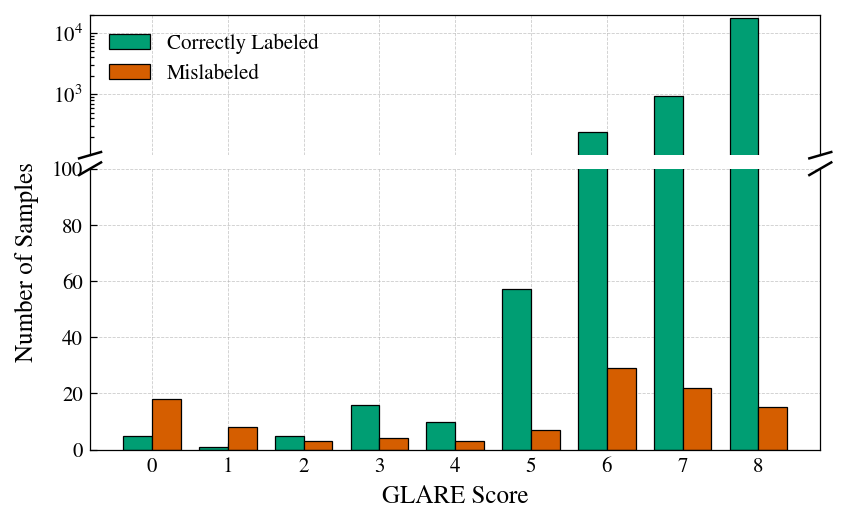

In [160]:
import matplotlib.gridspec as gridspec

score_vals      = list(range(MAX_SCORE + 1))
clean_counts    = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 0)).sum()) for s in score_vals]
mislabel_counts = [int(((scores_df["glare_score"] == s) & (scores_df["mislabeled"] == 1)).sum()) for s in score_vals]

lower_ylim = 100
top_ylim   = min(20000, int(np.ceil(max(clean_counts) * 1.15)))

fig = plt.figure(figsize=plotstyle.figsize(0.85, 0.6))
fig.get_layout_engine().set(hspace=0, h_pad=0.01)   # broken y-axis: keep the two panels together
gs  = fig.add_gridspec(2, 1, height_ratios=[1, 2])
ax_top    = fig.add_subplot(gs[0])
ax_bottom = fig.add_subplot(gs[1], sharex=ax_top)

x     = np.arange(len(score_vals))
bar_w = 0.38

for ax in (ax_top, ax_bottom):
    ax.bar(x - bar_w/2, clean_counts,    width=bar_w, color="#009E73", edgecolor="black", linewidth=0.6, label="Correctly Labeled")
    ax.bar(x + bar_w/2, mislabel_counts, width=bar_w, color="#D55E00", edgecolor="black", linewidth=0.6, label="Mislabeled")
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
    ax.set_axisbelow(True)

ax_top.set_yscale("log")                 # linear would leave the 238-bar invisible
ax_top.set_ylim(lower_ylim, top_ylim)
ax_top.set_yticks([1000, 10000])          # no 10^2 label next to the lower panel's 100
ax_bottom.set_ylim(0, lower_ylim)
ax_top.spines["bottom"].set_visible(False)
ax_bottom.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False, labelbottom=False)
ax_top.xaxis.set_major_formatter(plt.NullFormatter())
ax_bottom.xaxis.tick_bottom()

d = 0.015
for ax, y_vals in [(ax_top, (-d*1.5, +d*1.5)), (ax_bottom, (1-d*1.5, 1+d*1.5))]:
    kw = dict(transform=ax.transAxes, color="k", clip_on=False)
    ax.plot((-d, +d),   y_vals, **kw)
    ax.plot((1-d, 1+d), y_vals, **kw)

ax_bottom.set_xlabel("GLARE Score")
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(score_vals)
ax_top.tick_params(axis="both")
ax_bottom.tick_params(axis="both")
ax_top.legend(loc="upper left")
fig.supylabel("Number of Samples", fontsize=plt.rcParams["axes.labelsize"])   # default would be figure.labelsize (14.4 pt)
plotstyle.savefig(fig, "fig6_01_histogram_all_ep8_no_LO")
plt.show()


### Figure 6.2: Recall (a) and F1-score (b) across different fractions of training data checked for GLARE and GLAREx.


/tmp/ipykernel_3958450/477022955.py:20: RuntimeWarning: invalid value encountered in divide
  f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)


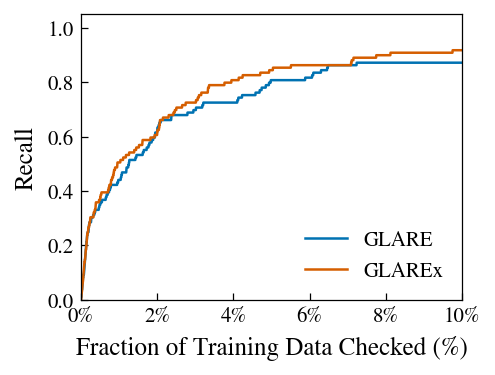

Total training samples: 19266 | GT mislabels: 109


In [161]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

scores = pd.read_csv(IN_NOLO_CSV)
gt     = pd.read_excel(IN_GT_XLSX)
scores["mislabeled"] = scores["id"].isin(set(gt["sample_id"].values)).astype(int)

def all_curves(df, score_col):
    sorted_df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=True).reset_index(drop=True)
    n         = len(sorted_df)
    n_pos     = int(sorted_df["mislabeled"].sum())
    fracs     = np.arange(1, n + 1) / n
    cum_found = sorted_df["mislabeled"].cumsum().values
    k         = np.arange(1, n + 1)
    recall    = cum_found / n_pos
    precision = cum_found / k
    denom     = precision + recall
    f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
    return fracs, recall, f1

fracs_g,  rec_g,  f1_g  = all_curves(scores, "glare score")
fracs_gx, rec_gx, f1_gx = all_curves(scores, "glarex score")

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.49, 0.75))
ax.plot(fracs_g * 100,  rec_g,  color="#0072B2", label="GLARE")
ax.plot(fracs_gx * 100, rec_gx, color="#D55E00", label="GLAREx")
ax.set_xlabel(f"Fraction of Training Data Checked ({PCT})")
ax.set_ylabel("Recall")
ax.set_xlim(0, 10)                           # same x-axis as Fig 6.10
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plotstyle.savefig(fig, "fig6_02a_glare_glarex_recall_curve")
plt.show()
print(f"Total training samples: {len(scores)} | GT mislabels: {int(scores['mislabeled'].sum())}")


/tmp/ipykernel_3958450/22190150.py:20: RuntimeWarning: invalid value encountered in divide
  f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)


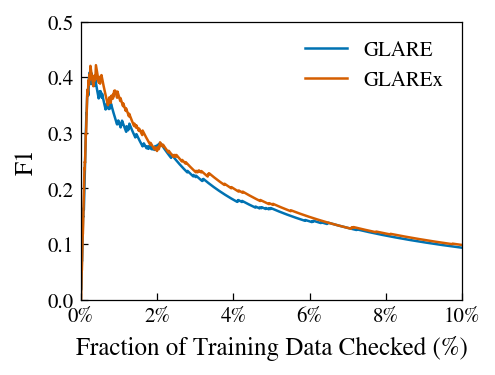

Total training samples: 19266 | GT mislabels: 109


In [162]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

scores = pd.read_csv(IN_NOLO_CSV)
gt     = pd.read_excel(IN_GT_XLSX)
scores["mislabeled"] = scores["id"].isin(set(gt["sample_id"].values)).astype(int)

def all_curves(df, score_col):
    sorted_df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=True).reset_index(drop=True)
    n         = len(sorted_df)
    n_pos     = int(sorted_df["mislabeled"].sum())
    fracs     = np.arange(1, n + 1) / n
    cum_found = sorted_df["mislabeled"].cumsum().values
    k         = np.arange(1, n + 1)
    recall    = cum_found / n_pos
    precision = cum_found / k
    denom     = precision + recall
    f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
    return fracs, recall, f1

fracs_g,  rec_g,  f1_g  = all_curves(scores, "glare score")
fracs_gx, rec_gx, f1_gx = all_curves(scores, "glarex score")

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.49, 0.75))
ax.plot(fracs_g * 100,  f1_g,  color="#0072B2", label="GLARE")
ax.plot(fracs_gx * 100, f1_gx, color="#D55E00", label="GLAREx")
ax.set_xlabel(f"Fraction of Training Data Checked ({PCT})")
ax.set_ylabel("F1")
ax.set_xlim(0, 10)                           # same x-axis as Fig 6.10
ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 0.5)
ax.legend(loc="upper right")
plotstyle.savefig(fig, "fig6_02b_glare_glarex_f1_curve")
plt.show()
print(f"Total training samples: {len(scores)} | GT mislabels: {int(scores['mislabeled'].sum())}")


### Figure 6.3: GLARE score distribution for mislabels introduced by a T11 enumeration anomaly.


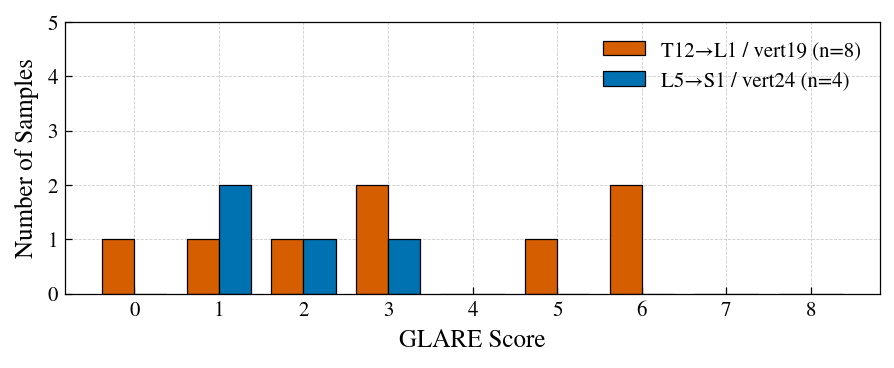

In [163]:
# ── Histogram: T12-missing ep-8 — T12→L1 (vert19) vs L5→S1 (vert24) ─────────
v19_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 19)]["sample_id"].astype(str))
v24_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 24)]["sample_id"].astype(str))

v19_df_8 = scores_df_8[scores_df_8["id"].isin(v19_ids)]
v24_df_8 = scores_df_8[scores_df_8["id"].isin(v24_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v19_counts_8 = [int((v19_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v24_counts_8 = [int((v24_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.9, 0.4))
ax.bar(x - bar_w/2, v19_counts_8, width=bar_w, color="#D55E00", edgecolor="black", linewidth=0.6, label=f"T12→L1 / vert19 (n={len(v19_df_8)})")
ax.bar(x + bar_w/2, v24_counts_8, width=bar_w, color="#0072B2", edgecolor="black", linewidth=0.6, label=f"L5→S1 / vert24 (n={len(v24_df_8)})")
ax.set_xlabel("GLARE Score")
ax.set_ylabel("Number of Samples")
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 5)
ax.set_yticks(range(0, 6, 1))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend()
plotstyle.savefig(fig, "fig6_03_histogram_T12missing_ep8_no_LO")
plt.show()


### Figure 6.4: GLARE score distribution for mislabels introduced by a T13 enumeration anomaly.


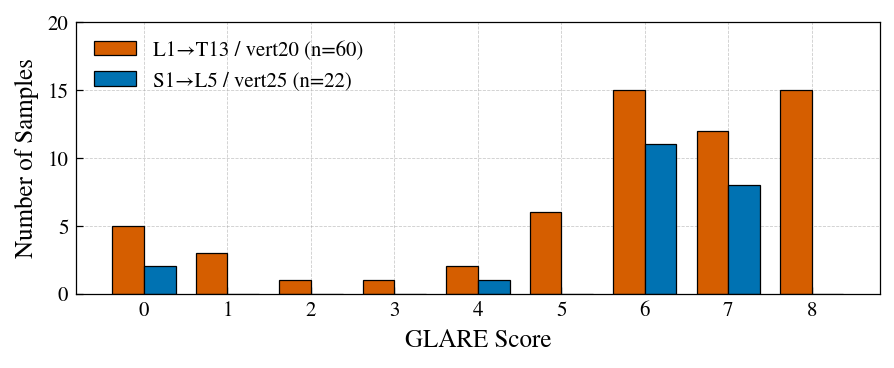

In [164]:
# ── Histogram: T13-extra — L1→T13 (vert20) vs S1→L5 (vert25) ────────────────
v20_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 20)]["sample_id"].astype(str))
v25_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 25)]["sample_id"].astype(str))

v20_df = scores_df[scores_df["id"].isin(v20_ids)]
v25_df = scores_df[scores_df["id"].isin(v25_ids)]

score_vals = list(range(MAX_SCORE + 1))
v20_counts = [int((v20_df["glare_score"] == s).sum()) for s in score_vals]
v25_counts = [int((v25_df["glare_score"] == s).sum()) for s in score_vals]

x     = np.arange(len(score_vals))
bar_w = 0.38

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.9, 0.4))
ax.bar(x - bar_w/2, v20_counts, width=bar_w, color="#D55E00", edgecolor="black", linewidth=0.6, label=f"L1→T13 / vert20 (n={len(v20_df)})")
ax.bar(x + bar_w/2, v25_counts, width=bar_w, color="#0072B2", edgecolor="black", linewidth=0.6, label=f"S1→L5 / vert25 (n={len(v25_df)})")
ax.set_xlabel("GLARE Score")
ax.set_ylabel("Number of Samples")
ax.set_xticks(x)
ax.set_xticklabels(score_vals)
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 5))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend()
plotstyle.savefig(fig, "fig6_04_histogram_T13extra_ep8_no_LO")
plt.show()


### Figure 6.5: GLARE score distribution for other types of mislabels in the data.


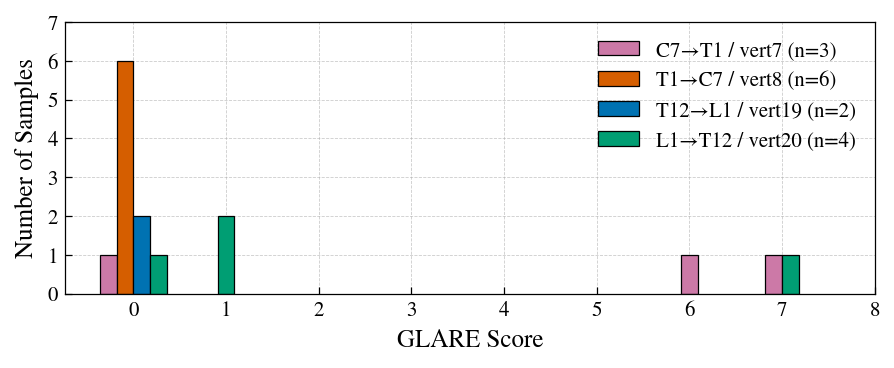

In [165]:
# ── Histogram: LabelShift ep-8 — C/T and T/L boundary mislabels ──────────────
import matplotlib.patches as mpatches

groups = [
    ("label_shift_C_as_T", 7,  "C7→T1 / vert7",  "#CC79A7"),
    ("label_shift_T_as_C", 8,  "T1→C7 / vert8",  "#D55E00"),
    ("label_shift_TL",     19, "T12→L1 / vert19", "#0072B2"),
    ("label_shift_TL",     20, "L1→T12 / vert20", "#009E73"),
]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
x     = np.arange(len(score_vals_8))
bar_w = 0.18

# Pre-compute counts per group
group_counts = []
group_meta   = []
for atype, vert, label_str, color in groups:
    ids = set(df_rc[(df_rc["anomaly_type"] == atype) & (df_rc["vert_id"] == vert)]["sample_id"].astype(str))
    sub = scores_df_8[scores_df_8["id"].isin(ids)]
    group_counts.append([int((sub["glare_score"] == s).sum()) for s in score_vals_8])
    group_meta.append((label_str, color, len(sub)))

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.9, 0.4))

for gi, (counts, (label_str, color, n_sub)) in enumerate(zip(group_counts, group_meta)):
    for si, (xi, cnt) in enumerate(zip(x, counts)):
        if cnt == 0:
            continue
        active   = [g for g in range(len(groups)) if group_counts[g][si] > 0]
        n_active = len(active)
        rank     = active.index(gi)
        offset   = (rank - (n_active - 1) / 2) * bar_w
        ax.bar(xi + offset, cnt, width=bar_w, color=color,
               edgecolor="black", linewidth=0.6)

legend_handles = [
    mpatches.Patch(facecolor=color, edgecolor="black", linewidth=0.6,
                   label=f"{label_str} (n={n})")
    for label_str, color, n in group_meta
]

ax.set_xlabel("GLARE Score")
ax.set_ylabel("Number of Samples")
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 7)
ax.set_yticks(range(0, 8, 1))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend(handles=legend_handles)
plotstyle.savefig(fig, "fig6_05_histogram_LabelShift_ep8_no_LO")
plt.show()


#### Setup B: per-sample gradient-norm curves, no-LO run (`grad_norm_curves.ipynb`)

In [166]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   # thesis style on a clean rcParams state


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [167]:
if not IN_CT_DIR.exists():
    raise RuntimeError(
        f"CT crops not found at {IN_CT_DIR}. "
        "Set MISLABELDET_DATASET_DIR to your prepared/ directory. "
        "These figures require the CT data (74 GB, not shipped with the repo)."
    )

import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

with open(IN_NOLO_GRAD_NORMS, "rb") as f:
    gn = pickle.load(f)

CLASS_NAMES = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}
N_EPOCHS = 8
PREPARED = str(IN_CT_DIR)
FIGURES_DIR = str(OUT_FIG_DIR)

def get_grad_norms(sample_id):
    rows = gn[gn["id"] == sample_id].sort_values("epoch")
    return rows[["c0_grad_norm", "c1_grad_norm", "c2_grad_norm", "c3_grad_norm"]].values

def load_ct_slice(npz_path):
    img = np.load(npz_path)["img"]
    mid_d = img.shape[0] // 2
    slc = img[mid_d, :, :]
    ch, cw = slc.shape[0] // 2, slc.shape[1] // 2
    half = 50
    return slc[ch - half : ch + half, cw - half : cw + half]

def plot_samples(samples, save_as=None):
    """Plot gradient norm curves for 2 or 3 samples side by side.
    Each sample tuple: (sample_id, assigned, true_cls, alt_cls, score, npz_path)
    For clean samples set assigned == true_cls; set alt_cls to show a competing class or -1 to hide.
    """
    n = len(samples)
    fig, axes = plt.subplots(1, n, figsize=plotstyle.figsize(1.0, 0.45))
    if n == 1:
        axes = [axes]

    for ax, (sid, assigned, true_cls, alt_cls, score, npz_path) in zip(axes, samples):
        norms = get_grad_norms(sid)
        epochs = np.arange(N_EPOCHS)
        pct = int(score / N_EPOCHS * 100)
        is_clean = (assigned == true_cls)

        ax.set_title(f"GLARE: {score} ({pct}{PCT})")

        if is_clean:
            ax.plot(epochs, norms[:, assigned], color="#009E73",
                    label=f"Label ({CLASS_NAMES[assigned]})")
            if alt_cls >= 0 and alt_cls != assigned:
                ax.plot(epochs, norms[:, alt_cls], color="#0072B2",
                        label=f"GLARE Alt. ({CLASS_NAMES[alt_cls]})",
                        linestyle="--")
        else:
            ax.plot(epochs, norms[:, assigned], color="#D55E00",
                    label=f"Label ({CLASS_NAMES[assigned]})")

            if alt_cls == true_cls:
                true_label = (f"True Label ({CLASS_NAMES[true_cls]}) /\n"
                              f"GLARE Alt. ({CLASS_NAMES[alt_cls]})")
            else:
                true_label = f"True Label ({CLASS_NAMES[true_cls]})"
            ax.plot(epochs, norms[:, true_cls], color="#009E73",
                    label=true_label)

            if alt_cls != true_cls and score < N_EPOCHS:
                ax.plot(epochs, norms[:, alt_cls], color="#0072B2",
                        label=f"GLARE Alt. ({CLASS_NAMES[alt_cls]})",
                        linestyle="--")

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Gradient Norm")
        ax.set_xticks(epochs)
        ax.set_ylim(-0.05 * 100, 100)   # 5 % margin below 0 like the x-axis, so zero gradients stay visible
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22))   # just below the x-label
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        inset = ax.inset_axes(plotstyle.inset_box(ax, 0.36, 0.47))   # top left, or top right if the curves run there
        slc = load_ct_slice(f"{PREPARED}/{npz_path}")
        inset.imshow(slc, cmap="gray", aspect="equal")
        inset.axis("off")


    plotstyle.fix_axes(fig, [ax.get_legend() for ax in axes])   # same box size in 6.6-6.8, whatever the legend length

    if save_as:
        plotstyle.savefig(fig, os.path.splitext(save_as)[0])
        print(f"Saved: {plotstyle.FIG_DIR / save_as}")

    plt.show()

print("Ready. Loaded", len(gn), "rows.")


Ready. Loaded 154128 rows.


### Figure 6.6: Comparison of gradient norm curves for mislabeled samples at T12 level. The left plot shows the gradient norm curves for a sample with a GLARE score of 0, and the right shows a sample with a higher GLARE score of 6.


Saved: /home/student/lisa_ma/figures/fig6_06_grad_norm_T12_missing.pdf


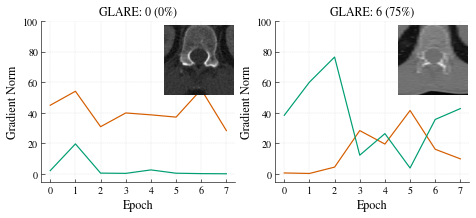

In [168]:
T12_SAMPLES = [
    ("verse626_dir-iso_vert19",          1, 2, 2, 0,
     "dataset-verse20/train/segment0.8mm_vert20_sub-verse626_dir-iso.npz"),
    ("ID0387_ses-25062010_ce-pv_vert19", 1, 2, 2, 6,
     "dataset-sagthomas/train/segment0.8mm_vert20_sub-ID0387_ses-25062010_ce-pv.npz"),
]

plot_samples(T12_SAMPLES, save_as="fig6_06_grad_norm_T12_missing.pdf")


### Figure 6.7: Comparison of gradient norm curves for mislabeled samples at the T13 level. The left plot shows the gradient norm curves for a sample with a GLARE score of 0 and the right shows a sample with a GLARE score of 8.



Saved: /home/student/lisa_ma/figures/fig6_07_grad_norm_T13_extra.pdf


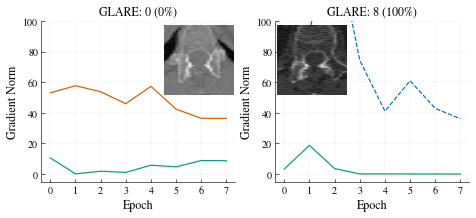

In [169]:
T13_SAMPLES = [
    ("ctfu00897_ses-20170303_ce-art_vert20", 2, 1, 1, 0,
     "dataset-ctfu1org/train/segment0.8mm_vert28_sub-ctfu00897_ses-20170303_ce-art.npz"),
    # Clean L1 (correctly labeled Lumbar, GLARE score 8)
    ("ID0009_ses-26102010_ce-pv_vert20",      2, 2, 0, 8,
     "dataset-sagthomas/train/segment0.8mm_vert20_sub-ID0009_ses-26102010_ce-pv.npz"),
]

plot_samples(T13_SAMPLES, save_as="fig6_07_grad_norm_T13_extra.pdf")


### Figure 6.8: Comparison of gradient norm curves for correctly labeled samples.



Saved: /home/student/lisa_ma/figures/fig6_08_grad_norm_correct.pdf


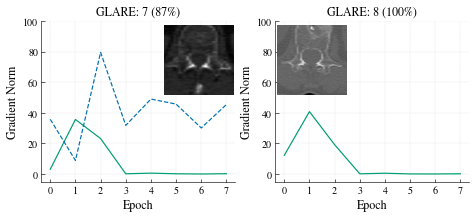

In [170]:
CLEAN_SAMPLES = [
    ("ATL057_dir-sag_split-WS_vert20", 2, 2, 1, 7,
     "dataset-ATL/train/segment0.8mm_vert20_sub-ATL057_dir-sag_split-WS.npz"),
    ("ATL028_dir-sag_split-WS_vert20", 2, 2, -1, 8,
     "dataset-ATL/train/segment0.8mm_vert20_sub-ATL028_dir-sag_split-WS.npz"),
]

plot_samples(CLEAN_SAMPLES, save_as="fig6_08_grad_norm_correct.pdf")


#### Setup C: GLARE/GLAREx from only the first N checkpoints, no-LO run (`early_epoch_comparison.ipynb`); ~7 min

In [171]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   # thesis style on a clean rcParams state


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [172]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
from sklearn.metrics import roc_auc_score
# which changes how GLARE ties are ordered in the recall/F1 curves)

%matplotlib inline
# (the source's rcParams.update is replaced by plotstyle.use() in the setup cell above)


In [173]:
import re, os

def calculate_glare(grad_norms):
    grad_norm_cols = sorted([col for col in grad_norms.columns if col.endswith('_grad_norm')])
    n_classes = len(grad_norm_cols)
    n_epoch = grad_norms["epoch"].max() + 1

    n_classes_from_labels = int(grad_norms['label'].max()) + 1
    assert n_classes == n_classes_from_labels, (
        f"n_classes from grad_norm columns ({n_classes}) != n_classes from labels ({n_classes_from_labels}). "
        "Not all classes may be present in training labels."
    )

    print(f"DEBUG: n_classes={n_classes}, n_epoch={n_epoch}")
    
    scores_list = []
    
    def max_index_excluding_class_x(lst, x):
        filtered_list = np.delete(lst, x)
        max_value = max(filtered_list)
        max_index = np.where(lst==max_value)[0][0]
        return max_index

    # Calculate GLARE scores for each sample ID
    for sample_id in grad_norms['id'].unique():
        sample_data = grad_norms[grad_norms['id'] == sample_id]
        
        if len(sample_data) == 0:
            continue
            
        label = int(sample_data['label'].iloc[0])
        
        glare = np.zeros(n_classes)
        grad_norm_in_min_epochs = np.zeros(n_classes)
        grad_norm_total = np.zeros(n_classes)
        
        # Process each epoch for sample
        for epoch in range(n_epoch):
            epoch_data = sample_data[sample_data['epoch'] == epoch]
            
            if len(epoch_data) == 0:
                continue
                
            # Get gradient norms for all classes in this epoch
            epoch_values = np.zeros(n_classes)
            for c in range(n_classes):
                col_name = f"c{c}_grad_norm"
                if col_name in epoch_data.columns:
                    epoch_values[c] = epoch_data[col_name].iloc[0]
            
            # Find class with minimum gradient
            min_class = np.argmin(epoch_values)
            glare[min_class] += 1
            grad_norm_in_min_epochs[min_class] += epoch_values[min_class]
            grad_norm_total += epoch_values
        
        # Skip if no valid data
        if np.sum(grad_norm_total) == 0:
            continue
            
        alt_class_glare = max_index_excluding_class_x(glare, label)
        
        # Calculate GLAREX scores
        glarex = np.zeros(n_classes)
        for c in range(n_classes):
            if glare[c] > 0:
                avg = grad_norm_in_min_epochs[c] / glare[c]
                inv_avg = 1.0 / avg if avg > 0 else 0
                glarex[c] = glare[c] + 0.01 * inv_avg
            else:
                avg = grad_norm_total[c] / n_epoch
                inv_avg = 1.0 / avg if avg > 0 else 0
                glarex[c] = glare[c] + 0.01 * inv_avg

        alt_class_glarex = max_index_excluding_class_x(glarex, label)
        
        scores_list.append([
            sample_id, 
            label,
            int(glare[label]), 
            float(glarex[label]), 
            alt_class_glare,
            int(glare[int(alt_class_glare)]),
            alt_class_glarex,
            float(glarex[int(alt_class_glarex)])])

    scores_df = pd.DataFrame(scores_list, columns=[
        "id", 
        "label", 
        "glare score", 
        "glarex score",
        "alternative class (glare)",
        "alternative glare score",
        "alternative class (glarex)",
        "alternative glarex score"])
    
    return scores_df


In [174]:
GRAD_NORMS_PKL = IN_NOLO_GRAD_NORMS
GT_XLSX        = IN_GT_XLSX
OUTPUT_DIR     = OUT_FIG_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [175]:
gn        = pd.read_pickle(GRAD_NORMS_PKL)
df_gt     = pd.read_excel(GT_XLSX, dtype=str)
positives = set(df_gt["sample_id"].astype(str))

total_epochs = int(gn["epoch"].max()) + 1
n_values     = list(range(1, total_epochs + 1))

print(f"Epochs available : {total_epochs}")
print(f"GT mislabels     : {len(positives)}")
print(f"Total samples    : {gn['id'].nunique()}")


Epochs available : 8
GT mislabels     : 109
Total samples    : 19266


In [176]:
def compute_auroc(scores_df, positives, score_col):
    y_true   = scores_df["id"].isin(positives).astype(int).values
    scores   = scores_df[score_col].values
    inverted = scores.max() - scores
    return roc_auc_score(y_true, inverted) if len(set(y_true)) > 1 else float("nan")

def recall_at_budget(scores_df, positives, score_col, budget_fracs):
    """Recall at fixed inspection budgets (fraction of training data checked)."""
    df = scores_df.copy()
    df["is_mislabel"] = df["id"].isin(positives).astype(int)
    df_sorted   = df.sort_values(score_col, ascending=True).reset_index(drop=True)
    total       = len(df_sorted)
    total_mis   = df_sorted["is_mislabel"].sum()
    cum_tp      = df_sorted["is_mislabel"].cumsum().values
    result = {}
    for frac in budget_fracs:
        k = max(1, int(np.ceil(frac * total))) - 1
        result[frac] = cum_tp[min(k, total - 1)] / total_mis if total_mis > 0 else 0.0
    return result

def threshold_table(scores_df, positives, n_epochs):
    """Integer threshold table for GLARE scores (same format as thesis table)."""
    y_true = scores_df["id"].isin(positives).astype(int).values
    scores = scores_df["glare score"].values.astype(int)
    rows = []
    for k in range(n_epochs):
        flagged   = scores <= k
        tp = int((flagged & (y_true == 1)).sum())
        fp = int((flagged & (y_true == 0)).sum())
        fn = int((~flagged & (y_true == 1)).sum())
        tn = int((~flagged & (y_true == 0)).sum())
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1        = 2*precision*recall / (precision+recall) if (precision+recall) > 0 else 0.0
        rows.append(dict(
            threshold=k, flagged=tp+fp,
            frac_pct=round((tp+fp)/len(y_true)*100, 2),
            recall_pct=round(recall*100, 1),
            precision_pct=round(precision*100, 1),
            f1_pct=round(f1*100, 1),
            TP=tp, FP=fp, FN=fn, TN=tn,
        ))
    return pd.DataFrame(rows)

# Shared color palette for N=1..8, consistent across plots 3/4/5.
# Extends Plot 2's budget palette (teal, green, orange, red, purple) with
# navy and blue at the low end and medium purple before dark purple.
_EPOCH_COLOR_LIST = ["#2C3E50", "#2980B9", "#1ABC9C", "#2ECC71",
                     "#F39C12", "#E74C3C", "#9B59B6", "#8E44AD"]
EPOCH_COLORS = {n: _EPOCH_COLOR_LIST[i] for i, n in enumerate(range(1, 9))}


In [ ]:
BUDGETS = [0.005, 0.01, 0.02, 0.05, 0.10]  # 0.5%, 1%, 2%, 5%, 10%

results = []  # summary rows
all_scores   = {}  # n -> scores_df
all_tables   = {}  # n -> threshold_df

for n in n_values:
    subset    = gn[gn["epoch"] < n].copy()
    scores_df = calculate_glare(subset)
    all_scores[n]  = scores_df
    all_tables[n]  = threshold_table(scores_df, positives, n)

    auroc_g  = compute_auroc(scores_df, positives, "glare score")
    auroc_gx = compute_auroc(scores_df, positives, "glarex score")
    rb_g     = recall_at_budget(scores_df, positives, "glare score",  BUDGETS)
    rb_gx    = recall_at_budget(scores_df, positives, "glarex score", BUDGETS)

    row = {"N": n, "AUROC_GLARE": auroc_g, "AUROC_GLAREx": auroc_gx}
    for b in BUDGETS:
        row[f"Recall_GLARE_{int(b*100)}pct"]  = round(rb_g[b]  * 100, 1)
        row[f"Recall_GLAREx_{int(b*100)}pct"] = round(rb_gx[b] * 100, 1)
    results.append(row)
    print(f"N={n:2d}  GLARE={auroc_g:.4f}  GLAREx={auroc_gx:.4f}")

df_summary = pd.DataFrame(results)


DEBUG: n_classes=4, n_epoch=1


N= 1  GLARE=0.7239  GLAREx=0.9354
DEBUG: n_classes=4, n_epoch=2
N= 2  GLARE=0.8722  GLAREx=0.9627
DEBUG: n_classes=4, n_epoch=3


### Figure 6.9: Recall from 0% to 10% of training data checked when GLARE (left) and GLAREx (right) are computed from only the first N = 1…8 epoch checkpoints.



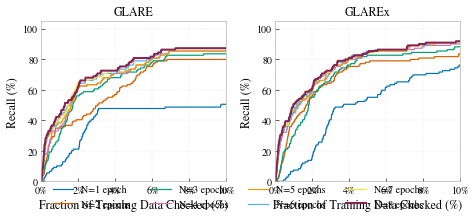

In [ ]:
colors_n  = dict(zip(n_values, [c if c.lower() != "#000000" else "#882255"   # Okabe–Ito, N = 1..8;
                             for c in plt.rcParams["axes.prop_cycle"].by_key()["color"]]))  # N=8 not black

fig, axes = plt.subplots(1, 2, figsize=plotstyle.figsize(1.0, 0.45))   # plus the legend strip

for ax, (method, score_col) in zip(axes, [("GLARE", "glare score"), ("GLAREx", "glarex score")]):
    for n in n_values:
        df_s = all_scores[n].copy()
        df_s["is_mislabel"] = df_s["id"].isin(positives).astype(int)
        df_sorted = df_s.sort_values(score_col, ascending=True).reset_index(drop=True)
        total     = len(df_sorted)
        total_mis = df_sorted["is_mislabel"].sum()
        cum_tp    = df_sorted["is_mislabel"].cumsum().values / total_mis
        fracs     = np.arange(1, total + 1) / total * 100

        lw = 2.0 if n == total_epochs else 1.2
        ax.plot(fracs, cum_tp * 100,
                color=colors_n[n], linewidth=lw,
                label=f"N={n} epoch{'s' if n > 1 else ''}")

    ax.set_xlabel(f"Fraction of Training Data Checked ({PCT})")
    ax.set_ylabel(f"Recall ({PCT})")
    ax.set_title(method)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.grid(True, linestyle="--", alpha=0.3)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6); sp.set_color("#AAAAAA")

leg = fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=4)
LAYOUT_6_9 = plotstyle.fix_axes(fig, [leg])   # the legend adds height instead of shrinking the boxes
plotstyle.savefig(fig, "fig6_09_recall_curves_by_n")
plt.show()


### Figure 6.10: F1 score from 0% to 10% of training data checked when GLARE (left) and GLAREx (right) are computed from only the first N = 1…8 epoch checkpoints.



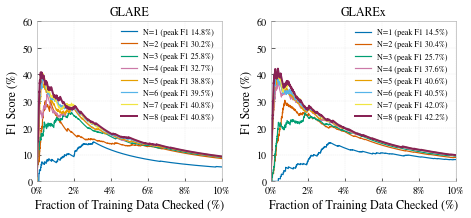


Peak F1 per N:

GLARE:
  N=1: peak F1 = 14.8%  at 3.09% checked
  N=2: peak F1 = 30.2%  at 0.47% checked
  N=3: peak F1 = 25.8%  at 1.89% checked
  N=4: peak F1 = 32.7%  at 0.58% checked
  N=5: peak F1 = 38.8%  at 0.29% checked
  N=6: peak F1 = 39.5%  at 0.33% checked
  N=7: peak F1 = 40.8%  at 0.25% checked
  N=8: peak F1 = 40.8%  at 0.22% checked

GLAREx:
  N=1: peak F1 = 14.5%  at 3.22% checked
  N=2: peak F1 = 30.4%  at 0.77% checked
  N=3: peak F1 = 25.7%  at 1.86% checked
  N=4: peak F1 = 37.6%  at 0.40% checked
  N=5: peak F1 = 40.6%  at 0.43% checked
  N=6: peak F1 = 40.5%  at 0.31% checked
  N=7: peak F1 = 42.0%  at 0.37% checked
  N=8: peak F1 = 42.2%  at 0.39% checked


In [ ]:
color_map3 = dict(zip(n_values, [c if c.lower() != "#000000" else "#882255"   # Okabe–Ito, N = 1..8;
                             for c in plt.rcParams["axes.prop_cycle"].by_key()["color"]]))  # N=8 not black

fig, axes = plt.subplots(1, 2, figsize=plotstyle.figsize(1.0, 0.45))   # same size as Fig 6.9 without its legend

for ax, (method, score_col) in zip(axes, [("GLARE", "glare score"), ("GLAREx", "glarex score")]):
    for n in n_values:
        df_s = all_scores[n].copy()
        df_s["is_mislabel"] = df_s["id"].isin(positives).astype(int)
        df_sorted  = df_s.sort_values(score_col, ascending=True).reset_index(drop=True)
        total      = len(df_sorted)
        total_mis  = df_sorted["is_mislabel"].sum()
        cum_tp     = df_sorted["is_mislabel"].cumsum().values
        inspected  = np.arange(1, total + 1)
        f1_curve   = np.where(inspected + total_mis > 0,
                              2 * cum_tp / (inspected + total_mis), 0.0)
        fracs      = inspected / total * 100

        lw = 2.0 if n == total_epochs else 1.2
        peak_f1 = f1_curve.max() * 100
        ax.plot(fracs, f1_curve * 100,
                color=color_map3[n], linewidth=lw,
                label=f"N={n} (peak F1 {peak_f1:.1f}{PCT})")

    ax.set_xlabel(f"Fraction of Training Data Checked ({PCT})")
    ax.set_ylabel(f"F1 Score ({PCT})")
    ax.set_title(method)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 60)   # room for the legend above the curves
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.legend(loc="upper right", fontsize=8, framealpha=0.95,
              edgecolor="#CCCCCC", fancybox=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6); sp.set_color("#AAAAAA")

plotstyle.fix_axes(fig, like=LAYOUT_6_9)      # same boxes as Fig 6.9 (run that cell first)
plotstyle.savefig(fig, "fig6_10_f1_curves")
plt.show()

# Peak F1 per N
print("\nPeak F1 per N:")
for method, score_col in [("GLARE", "glare score"), ("GLAREx", "glarex score")]:
    print(f"\n{method}:")
    for n in n_values:
        df_s = all_scores[n].copy()
        df_s["is_mislabel"] = df_s["id"].isin(positives).astype(int)
        df_sorted = df_s.sort_values(score_col, ascending=True).reset_index(drop=True)
        total_mis = df_sorted["is_mislabel"].sum()
        cum_tp    = df_sorted["is_mislabel"].cumsum().values
        inspected = np.arange(1, len(df_sorted) + 1)
        f1_curve  = 2 * cum_tp / (inspected + total_mis)
        print(f"  N={n}: peak F1 = {f1_curve.max()*100:.1f}%  at {inspected[f1_curve.argmax()]/len(df_sorted)*100:.2f}% checked")


#### Setup D: LO run (`evaluation_ep8_with_LO.ipynb`)

In [ ]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   # thesis style on a clean rcParams state


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import accuracy_score, recall_score, f1_score

MISLABELS_CSV = IN_LO_CSV
RC_XLSX       = IN_GT_LO_XLSX
MAX_SCORE     = 8

scores_df = pd.read_csv(MISLABELS_CSV, dtype=str, keep_default_na=False)
scores_df["glare_score"] = pd.to_numeric(scores_df["glare score"], errors="coerce")
scores_df = scores_df.dropna(subset=["glare_score"]).reset_index(drop=True)


In [ ]:
# To get the mislabeled / clean label
df_rc     = pd.read_excel(RC_XLSX)                           # kein sheet_name nötig
positives = set(df_rc["sample_id"].astype(str))             # sample_id statt id, kein in_training_data Filter
scores_df["mislabeled"] = scores_df["id"].apply(lambda x: 1 if x in positives else 0)


In [ ]:
# ── ep-8 run (Sep 26 2026, single-gpu): load data ────────────────────────────
MISLABELS_CSV_8 = IN_LO_CSV
MAX_SCORE_8 = 8

scores_df_8 = pd.read_csv(MISLABELS_CSV_8, dtype=str, keep_default_na=False)
scores_df_8["glare_score"] = pd.to_numeric(scores_df_8["glare score"], errors="coerce")
scores_df_8 = scores_df_8.dropna(subset=["glare_score"]).reset_index(drop=True)
scores_df_8["mislabeled"] = scores_df_8["id"].apply(lambda x: 1 if x in positives else 0)

score_vals_8      = list(range(MAX_SCORE_8 + 1))
clean_counts_8    = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 0)).sum()) for s in score_vals_8]
mislabel_counts_8 = [int(((scores_df_8["glare_score"] == s) & (scores_df_8["mislabeled"] == 1)).sum()) for s in score_vals_8]


### Figure 6.11: Recall and F1 score across different fractions of training data checked for GLARE and GLAREx on the dataset with only T11 and T13 mislabels.


/tmp/ipykernel_3958450/3065887897.py:19: RuntimeWarning: invalid value encountered in divide
  f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
/tmp/ipykernel_3958450/3065887897.py:19: RuntimeWarning: invalid value encountered in divide
  f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)


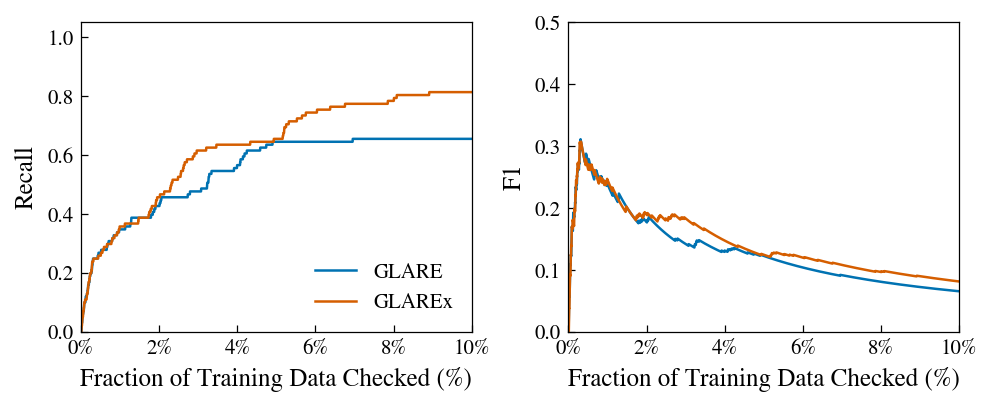

Fraction checked → Recall / F1 (GLARE | GLAREx)
  1%  GLARE  R=34.7%  F1=0.239  |  GLAREx  R=35.6%  F1=0.246
  5%  GLARE  R=64.4%  F1=0.122  |  GLAREx  R=65.3%  F1=0.124
  10%  GLARE  R=65.3%  F1=0.065  |  GLAREx  R=81.2%  F1=0.081
  20%  GLARE  R=69.3%  F1=0.035  |  GLAREx  R=94.1%  F1=0.048
  50%  GLARE  R=80.2%  F1=0.017  |  GLAREx  R=100.0%  F1=0.021


In [ ]:
# ── Rank-based Recall / F1 Curves — GLARE vs GLAREx (ep-8 new) ───────────────
import matplotlib.ticker as mticker

scores_df_8["glarex_score"] = pd.to_numeric(scores_df_8.get("glarex score", pd.Series(dtype=float)), errors="coerce")

n_total_8     = len(scores_df_8)
n_mislabels_8 = int(scores_df_8["mislabeled"].sum())

def all_curves(df, score_col):
    sorted_df = df.dropna(subset=[score_col]).sort_values(score_col, ascending=True).reset_index(drop=True)
    n         = len(sorted_df)
    n_pos     = int(sorted_df["mislabeled"].sum())
    fracs     = np.arange(1, n + 1) / n
    cum_found = sorted_df["mislabeled"].cumsum().values
    k         = np.arange(1, n + 1)
    recall    = cum_found / n_pos
    precision = cum_found / k
    denom     = precision + recall
    f1        = np.where(denom > 0, 2 * precision * recall / denom, 0.0)
    return fracs, recall, f1

fracs_g,  rec_g,  f1_g  = all_curves(scores_df_8, "glare_score")
fracs_gx, rec_gx, f1_gx = all_curves(scores_df_8, "glarex_score")

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=plotstyle.figsize(1.0, 0.4))

ax_l.plot(fracs_g * 100,  rec_g,  color="#0072B2", label="GLARE")
ax_l.plot(fracs_gx * 100, rec_gx, color="#D55E00", label="GLAREx")
ax_l.set_xlabel(f"Fraction of Training Data Checked ({PCT})")
ax_l.set_ylabel("Recall")
ax_l.set_xlim(0, 10)                         # same x-axis as Fig 6.10
ax_l.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax_l.set_ylim(0, 1.05)
ax_l.legend(loc="lower right")
ax_l.set_facecolor("white")
ax_l.grid(False)

ax_r.plot(fracs_g * 100,  f1_g,  color="#0072B2", label="GLARE")
ax_r.plot(fracs_gx * 100, f1_gx, color="#D55E00", label="GLAREx")
ax_r.set_xlabel(f"Fraction of Training Data Checked ({PCT})")
ax_r.set_ylabel("F1")
ax_r.set_xlim(0, 10)                         # same x-axis as Fig 6.10
ax_r.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax_r.set_ylim(0, 0.5)
ax_r.set_facecolor("white")
ax_r.grid(False)

plotstyle.savefig(fig, "fig6_11_recall_f1_curve_ep8_new")
plt.show()

print("Fraction checked → Recall / F1 (GLARE | GLAREx)")
for frac in [0.01, 0.05, 0.10, 0.20, 0.50]:
    i_g  = min(int(np.searchsorted(fracs_g,  frac, side="right")) - 1, len(fracs_g)  - 1)
    i_gx = min(int(np.searchsorted(fracs_gx, frac, side="right")) - 1, len(fracs_gx) - 1)
    print(f"  {frac:.0%}  GLARE  R={rec_g[i_g]:.1%}  F1={f1_g[i_g]:.3f}"
          f"  |  GLAREx  R={rec_gx[i_gx]:.1%}  F1={f1_gx[i_gx]:.3f}")


### Figure 6.12: GLARE score distribution for mislabels introduced by a T11 enumeration anomaly (T12→L1, n = 10; L5→S1, n = 6) in the updated dataset.



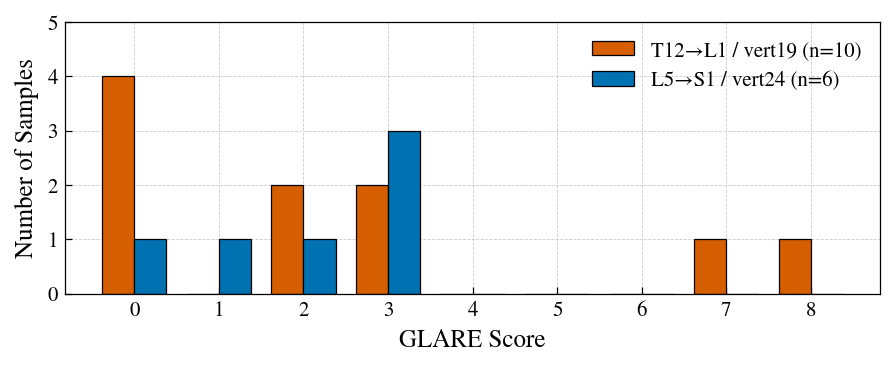

In [ ]:
# ── Histogram: T12-missing ep-8 new — T12→L1 (vert19) vs L5→S1 (vert24) ──────
v19_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 19)]["sample_id"].astype(str))
v24_ids = set(df_rc[(df_rc["anomaly_type"] == "T12_missing") & (df_rc["vert_id"] == 24)]["sample_id"].astype(str))

v19_df_8 = scores_df_8[scores_df_8["id"].isin(v19_ids)]
v24_df_8 = scores_df_8[scores_df_8["id"].isin(v24_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v19_counts_8 = [int((v19_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v24_counts_8 = [int((v24_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.9, 0.4))
ax.bar(x - bar_w/2, v19_counts_8, width=bar_w, color="#D55E00", edgecolor="black", linewidth=0.6, label=f"T12→L1 / vert19 (n={len(v19_df_8)})")
ax.bar(x + bar_w/2, v24_counts_8, width=bar_w, color="#0072B2", edgecolor="black", linewidth=0.6, label=f"L5→S1 / vert24 (n={len(v24_df_8)})")
ax.set_xlabel("GLARE Score")
ax.set_ylabel("Number of Samples")
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.set_ylim(0, 5)
ax.set_yticks(range(0, 6, 1))
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend()
plotstyle.savefig(fig, "fig6_12_histogram_T12missing_ep8_new")
plt.show()


### Figure 6.13: GLARE score distribution for mislabels introduced by a T13 enumeration anomaly (L1→T13, n = 62; S1→L5, n = 23) in the updated dataset.


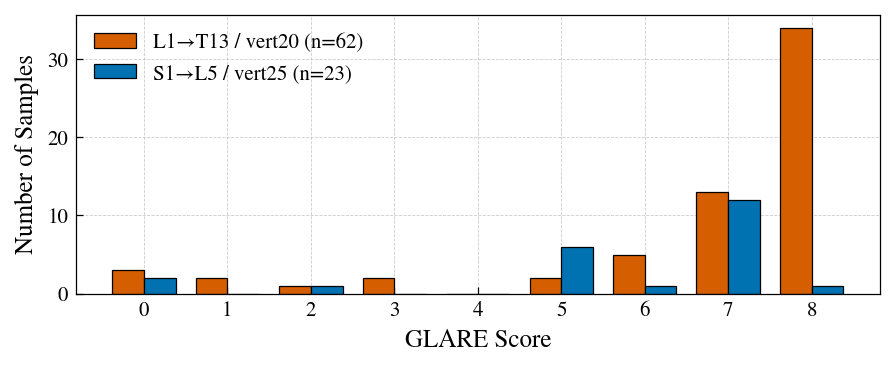

In [ ]:
# ── Histogram: T13-extra ep-8 new — L1→T13 (vert20) vs S1→L5 (vert25) ────────
v20_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 20)]["sample_id"].astype(str))
v25_ids = set(df_rc[(df_rc["anomaly_type"] == "T13_extra") & (df_rc["vert_id"] == 25)]["sample_id"].astype(str))

v20_df_8 = scores_df_8[scores_df_8["id"].isin(v20_ids)]
v25_df_8 = scores_df_8[scores_df_8["id"].isin(v25_ids)]

score_vals_8 = list(range(MAX_SCORE_8 + 1))
v20_counts_8 = [int((v20_df_8["glare_score"] == s).sum()) for s in score_vals_8]
v25_counts_8 = [int((v25_df_8["glare_score"] == s).sum()) for s in score_vals_8]

x     = np.arange(len(score_vals_8))
bar_w = 0.38

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.9, 0.4))
ax.bar(x - bar_w/2, v20_counts_8, width=bar_w, color="#D55E00", edgecolor="black", linewidth=0.6, label=f"L1→T13 / vert20 (n={len(v20_df_8)})")
ax.bar(x + bar_w/2, v25_counts_8, width=bar_w, color="#0072B2", edgecolor="black", linewidth=0.6, label=f"S1→L5 / vert25 (n={len(v25_df_8)})")
ax.set_xlabel("GLARE Score")
ax.set_ylabel("Number of Samples")
ax.set_xticks(x)
ax.set_xticklabels(score_vals_8)
ax.grid(True, linestyle="--", alpha=0.6, color="#AAAAAA")
ax.set_axisbelow(True)
ax.set_facecolor("white")
ax.legend()
plotstyle.savefig(fig, "fig6_13_histogram_T13extra_ep8_new")
plt.show()


#### Setup E: T13 analysis, LO run (`evaluation_script_T13.ipynb`)

In [ ]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   # thesis style on a clean rcParams state


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [ ]:
if not IN_CT_DIR.exists():
    raise RuntimeError(
        f"CT crops not found at {IN_CT_DIR}. "
        "Set MISLABELDET_DATASET_DIR to your prepared/ directory. "
        "These figures require the CT data (74 GB, not shipped with the repo)."
    )

import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
GLARE_CSV   = IN_LO_CSV
GT_CSV      = IN_GT_DERIVED_CSV
FILTER_XLS  = IN_FILTER_XLSX
SPEC_PATH   = IN_LO_SPEC
PREPARED    = IN_CT_DIR

SCORE_COL   = "glarex score"   # continuous score column
INT_SCORE   = "glare score"    # integer 0-8


In [ ]:
# ── Load GLARE scores ──────────────────────────────────────────────────────────
scores = pd.read_csv(GLARE_CSV)
scores = scores.rename(columns={"id": "sample_id"})

# ── Load GT mislabels — T13_extra vert20 only ─────────────────────────────────
gt = pd.read_csv(GT_CSV)
t13 = gt[(gt["anomaly_type"] == "T13_extra") & (gt["vert_id"] == 20)].copy()

# ── Merge scores with T13 GT ──────────────────────────────────────────────────
t13_scores = scores.merge(t13[["sample_id","pid","dsname","vert_id","source","disk_vert_id"]],
                          on="sample_id", how="inner")
print(f"GLARE total samples    : {len(scores)}")
print(f"T13 vert20 in GT       : {len(t13)}")
print(f"T13 vert20 in GLARE    : {len(t13_scores)}")
print()
print("Integer GLARE score distribution for T13 vert20 mislabels:")
print(t13_scores[INT_SCORE].value_counts().sort_index().to_string())


GLARE total samples    : 19266
T13 vert20 in GT       : 62
T13 vert20 in GLARE    : 62

Integer GLARE score distribution for T13 vert20 mislabels:
glare score
0     3
1     2
2     1
3     2
5     2
6     5
7    13
8    34


In [ ]:
# ── Build sample_id → file path mapping ───────────────────────────────────────
# File format: {PREPARED}/{dsname}/{split}/segment0.8mm_vert{disk_vert}_sub-{pid}.npz
# The disk_vert (orig vert in file name) differs from training_vert for Rule A/B PIDs.
# We invert pid_corrections to get disk_vert from training_vert.

with open(SPEC_PATH) as f:
    spec = json.load(f)
pid_fix_1820 = set(spec.get("pid_fix_1820", []))
pid_fix_28   = set(spec.get("pid_fix_28",   []))

fdf = pd.read_excel(FILTER_XLS)
fdf = fdf[(fdf["has_T1"]==1) & (fdf["is_consecutive"]==1)]
pid_meta = {
    str(r["pid"]).strip(): {
        "dsname": str(r["dsname"]).strip(),
        "split":  str(r["split"]).strip(),
        "disk_verts": set(int(v) for v in ast.literal_eval(str(r["vert_label"]))
                          if pd.notna(v)),
    }
    for _, r in fdf.iterrows()
}

def apply_rules(verts):
    if 28 in verts and 20 in verts:
        return {v: (20 if v==28 else (v+1 if v>=20 else v)) for v in verts}
    if 20 in verts and 19 not in verts and 18 in verts:
        return {v: (v-1 if v>=20 else v) for v in verts}
    return {v: v for v in verts}

# Build inv_corrections: {pid: {training_vert: disk_vert}}
inv_corrections = {}
for pid in pid_fix_1820 | pid_fix_28:
    if pid in pid_meta:
        corr = apply_rules(pid_meta[pid]["disk_verts"])
        inv_corrections[pid] = {tv: dv for dv, tv in corr.items()}

# Also handle LO PIDs via disk_vert_id in the GT table (already stored there)

def get_patch_path(pid, training_vert, dsname=None, split=None, disk_vert_id=None):
    """Resolve npz path for a training sample."""
    if pid not in pid_meta:
        return None
    meta  = pid_meta[pid]
    dname = dsname or meta["dsname"]
    spl   = split  or meta["split"]
    # disk_vert: use GT-provided disk_vert_id if available, else invert corrections
    if disk_vert_id and not pd.isna(disk_vert_id):
        disk_v = int(disk_vert_id)
    else:
        inv = inv_corrections.get(pid, {})
        disk_v = inv.get(training_vert, training_vert)
    path = PREPARED / dname / spl / f"segment0.8mm_vert{disk_v}_sub-{pid}.npz"
    return path if path.exists() else None

# Attach file paths to t13_scores
t13_scores["patch_path"] = t13_scores.apply(
    lambda r: get_patch_path(r["pid"], r["vert_id"], r["dsname"], disk_vert_id=r["disk_vert_id"]),
    axis=1
)
found = t13_scores["patch_path"].notna().sum()
print(f"Patch files found: {found} / {len(t13_scores)}")


Patch files found: 62 / 62


In [ ]:
# ── Patch loading helpers ──────────────────────────────────────────────────────
def load_mid_slice(path, view="sagittal"):
    """Load central 2-D slice from a 3-D CT patch (H×W×D).
    view: 'sagittal'=axis 0, 'coronal'=axis 1, 'axial'=axis 2
    """
    d    = np.load(path, allow_pickle=True)
    img  = d["img"].astype(np.float32)
    axis = {"sagittal": 0, "coronal": 1, "axial": 2}[view]
    mid  = img.shape[axis] // 2
    slc  = np.take(img, mid, axis=axis)
    slc  = np.clip(slc, -200, 1000)
    slc  = (slc + 200) / 1200
    return slc

def load_mid_slice_with_mask(path, target_vert_id, view="coronal", alpha=0.35):
    """Load central slice and return (img_slice, overlay_rgba) where the
    target vertebra is highlighted in red and others in blue."""
    d    = np.load(path, allow_pickle=True)
    img  = d["img"].astype(np.float32)
    msk  = d["msk"]
    axis = {"sagittal": 0, "coronal": 1, "axial": 2}[view]
    mid  = img.shape[axis] // 2
    img_slc = np.take(img, mid, axis=axis)
    msk_slc = np.take(msk, mid, axis=axis)
    img_slc = np.clip(img_slc, -200, 1000)
    img_slc = (img_slc + 200) / 1200

    H, W = img_slc.shape
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    # target vertebra: red
    target_mask = msk_slc == target_vert_id
    overlay[target_mask] = [1.0, 0.1, 0.1, alpha]
    # other vertebrae: blue
    other_mask = (msk_slc > 0) & ~target_mask
    overlay[other_mask] = [0.1, 0.4, 1.0, alpha * 0.5]
    return img_slc, overlay


In [ ]:
import pickle

GN_PKL = IN_LO_GRAD_NORMS
_gn = pickle.load(open(GN_PKL, "rb"))

N_EP         = 8
CLS_NAMES    = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}
ASSIGNED_CLS = 2   # Lumbar (wrong label for T13)
TRUE_CLS     = 1   # Thoracic (correct class)

def get_epoch_norms(sample_id):
    rows = _gn[_gn["id"] == sample_id].sort_values("epoch")
    return rows[["c0_grad_norm", "c1_grad_norm", "c2_grad_norm", "c3_grad_norm"]].values


### Figure 6.14: Expert comments on T13 enumeration anomalies with GLARE Score 8.



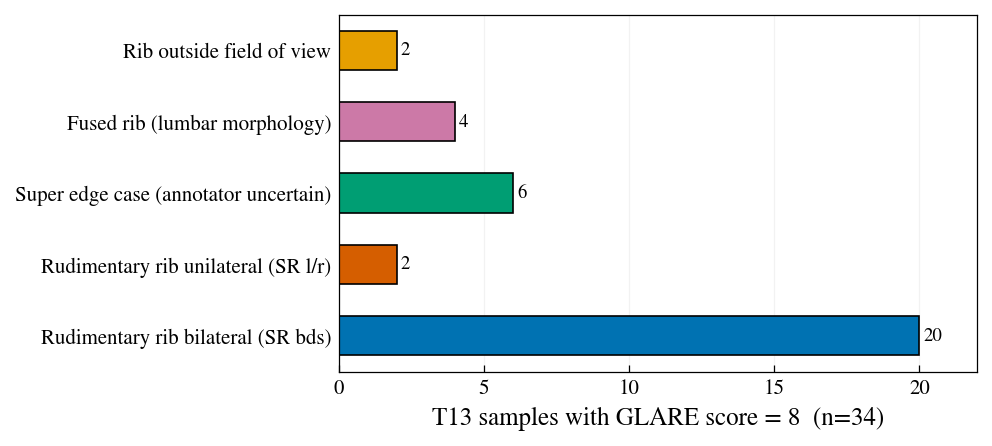

In [ ]:
# ── Missed T13 (score=8): annotation-based category breakdown ────────────────
_anom = pd.read_excel(IN_OLD_GT_XLSX)
_anom["scan_base"] = _anom["fid"]   # full fid — no split stripping
_anom_best = _anom.drop_duplicates("scan_base")

_t13_sc = scores.merge(
    pd.read_csv(GT_CSV).query("anomaly_type=='T13_extra' and vert_id==20")[["sample_id"]],
    on="sample_id", how="inner"
)
_missed8 = _t13_sc[_t13_sc[INT_SCORE] == 8].copy()
_missed8["scan_base"] = _missed8["sample_id"].str.replace(r"_vert\d+$", "", regex=True)
_missed8 = _missed8.merge(_anom_best[["scan_base", "HE Comment"]], on="scan_base", how="left")

def _cat(c):
    if pd.isna(c): return None
    c = str(c)
    if "SUPER EDGE CASE" in c:  return "Super edge case (annotator uncertain)"
    if "Type 4" in c:            return "Fused rib (lumbar morphology)"
    if "abgeschnitten" in c:     return "Rib outside field of view"
    if "bleibt T12" in c:        return "Rib seen, kept as T12"
    if "bds" in c:               return "Rudimentary rib bilateral (SR bds)"
    if "SR" in c:                return "Rudimentary rib unilateral (SR l/r)"
    return None

CAT_ORDER_B = [
    "Rudimentary rib bilateral (SR bds)",
    "Rudimentary rib unilateral (SR l/r)",
    "Super edge case (annotator uncertain)",
    "Fused rib (lumbar morphology)",
    "Rib outside field of view",
    "Rib seen, kept as T12",
]
CAT_COLORS_B = {
    "Rudimentary rib bilateral (SR bds)":    "#0072B2",
    "Rudimentary rib unilateral (SR l/r)":   "#D55E00",
    "Super edge case (annotator uncertain)":  "#009E73",
    "Fused rib (lumbar morphology)":          "#CC79A7",
    "Rib outside field of view":              "#E69F00",
    "Rib seen, kept as T12":                  "#56B4E9",
}

_missed8["category"] = _missed8["HE Comment"].apply(_cat)
_missed8 = _missed8.dropna(subset=["category"])
_counts_b = (_missed8["category"].value_counts()
             .reindex([c for c in CAT_ORDER_B if c in _missed8["category"].unique()]))

fig, ax = plt.subplots(figsize=plotstyle.figsize(1.0, 0.44))
y = np.arange(len(_counts_b))
ax.grid(axis="x", color="#e0e0e0", linewidth=0.6, zorder=1)
bars = ax.barh(y, _counts_b.values,
               color=[CAT_COLORS_B[c] for c in _counts_b.index],
               height=0.55, edgecolor="black", linewidth=0.8, zorder=3)

for bar in bars:
    w = bar.get_width()
    if w > 0:
        ax.text(w + 0.15, bar.get_y() + bar.get_height() / 2,
                str(int(w)), va="center", fontsize=9, zorder=4)

ax.set_yticks(y)
ax.set_yticklabels(_counts_b.index)
ax.set_xlabel(f"T13 samples with GLARE score = 8  (n={len(_missed8)})")
ax.set_xlim(0, _counts_b.max() + 2)
ax.set_xticks(range(0, int(_counts_b.max()) + 5, 5))
ax.spines["left"].set_zorder(4)
ax.spines["bottom"].set_zorder(4)
plotstyle.savefig(fig, "fig6_14_missed_T13_categories_bar")
plt.show()


### Figure 6.15: False positives (samples not in the ground truth) with a GLARE score ≤ 3 (n = 38), by vertebra and expert annotation.


Score ≤ 3 False Positives — Categories:
            category  samples  scans
                TLTV        2      2
             No ribs        4      4
Segmentation failure        4      1
          No anomaly        4      3
       Metal implant        1      1
       Not annotated       23     22

Total: 38 samples from 33 scans


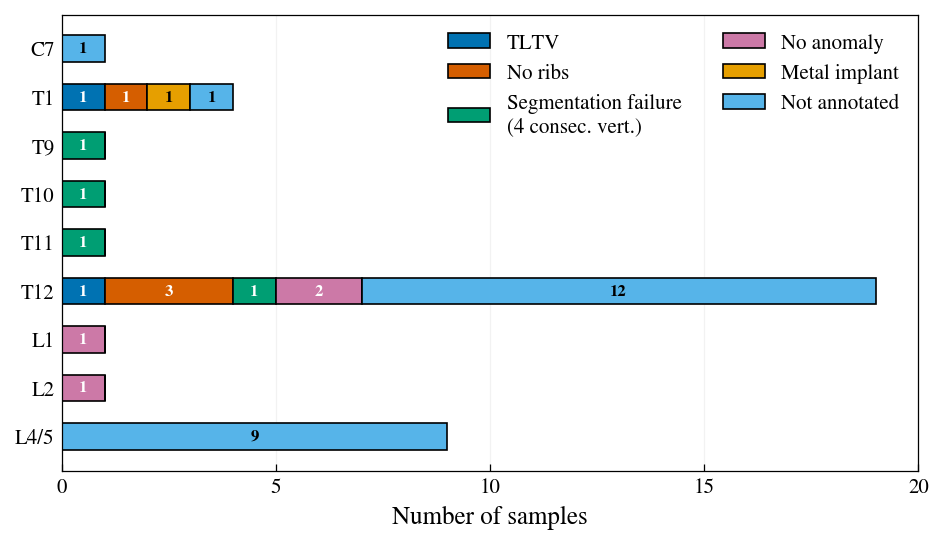

In [ ]:
# ── Score ≤ 3 false positives — vertebra distribution + anomaly categories ──
ANOM_XLS = IN_OLD_GT_XLSX

anom = pd.read_excel(ANOM_XLS)
anom["scan_base"] = anom["fid"].str.replace(r"_split-\S+$", "", regex=True)
anom_best = anom.sort_values("TLTV", ascending=False).drop_duplicates("scan_base")

fp3 = scores[scores[INT_SCORE] <= 3].copy()
fp3 = fp3[~fp3["sample_id"].isin(set(pd.read_csv(GT_CSV)["sample_id"]))]
fp3["vert_id"]   = fp3["sample_id"].str.extract(r"_vert(\d+)$").astype(int)
fp3["scan_base"] = fp3["sample_id"].str.replace(r"_vert\d+$", "", regex=True)

fp3 = fp3.merge(
    anom_best[["scan_base", "T11", "T13", "TLTV", "LabelOverride", "HE Comment"]],
    on="scan_base", how="left"
)

def assign_category(row):
    comment = str(row.get("HE Comment", "") or "")
    if row.get("TLTV") == 1:
        return "TLTV"
    if "Rippen" in comment or "rippen" in comment:
        return "No ribs"
    if "segfail" in comment.lower():
        return "Segmentation failure"
    if "Passt" in comment or "passt" in comment:
        return "No anomaly"
    if pd.notna(row.get("HE Comment")):
        return "Metal implant"
    return "Not annotated"

fp3["category"] = fp3.apply(assign_category, axis=1)

CAT_ORDER  = ["TLTV", "No ribs", "Segmentation failure", "No anomaly", "Metal implant", "Not annotated"]
CAT_COLORS = {
    "TLTV":                  "#0072B2",
    "No ribs":               "#D55E00",
    "Segmentation failure":  "#009E73",
    "No anomaly":            "#CC79A7",
    "Metal implant":         "#E69F00",
    "Not annotated":         "#56B4E9",
}
CAT_LEGEND = {
    "TLTV":                  "TLTV",
    "No ribs":               "No ribs",
    "Segmentation failure":  "Segmentation failure\n(4 consec. vert.)",
    "No anomaly":            "No anomaly",
    "Metal implant":         "Metal implant",
    "Not annotated":         "Not annotated",
}

cat_summary = (
    fp3.groupby("category")
    .agg(samples=("sample_id", "count"), scans=("scan_base", "nunique"))
    .reindex([c for c in CAT_ORDER if c in fp3["category"].unique()])
    .reset_index()
)
print("Score ≤ 3 False Positives — Categories:")
print(cat_summary[["category", "samples", "scans"]].to_string(index=False))
print(f"\nTotal: {len(fp3)} samples from {fp3['scan_base'].nunique()} scans")

VERT_LABEL = {7: "C7", 8: "T1", 16: "T9", 17: "T10", 18: "T11", 19: "T12", 20: "L1", 21: "L2", 24: "L4/5"}

vert_cat = (
    fp3.assign(vert_label=fp3["vert_id"].map(VERT_LABEL).fillna(fp3["vert_id"].astype(str)))
    .groupby(["vert_label", "category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in CAT_ORDER if c in fp3["category"].unique()])
)
# Lumbar at bottom, thoracic in middle, cervical at top
vert_order_plot = ["L4/5", "L2", "L1", "T12", "T11", "T10", "T9", "T1", "C7"]
vert_order_plot = [v for v in vert_order_plot if v in vert_cat.index]
vert_cat = vert_cat.reindex(vert_order_plot)

fig, ax_bar = plt.subplots(figsize=plotstyle.figsize(0.95, 0.57))
ax_bar.grid(axis="x", color="#e0e0e0", linewidth=0.6, zorder=1)

lefts = [0] * len(vert_cat)
for cat in vert_cat.columns:
    vals = vert_cat[cat].values
    bars = ax_bar.barh(vert_cat.index, vals, left=lefts,
                       color=CAT_COLORS[cat], label=CAT_LEGEND[cat], height=0.55, edgecolor="black", linewidth=0.8, zorder=3)
    for bar, v, l in zip(bars, vals, lefts):
        if v > 0:
            ax_bar.text(l + v / 2, bar.get_y() + bar.get_height() / 2,
                        str(v), ha="center", va="center",
                        fontsize=8, color="black" if cat in ("Metal implant", "Not annotated") else "white",
                        fontweight="bold", zorder=4)
    lefts = [l + v for l, v in zip(lefts, vals)]

ax_bar.set_xlabel("Number of samples")
ax_bar.set_xlim(0, 20)
ax_bar.set_xticks(range(0, 21, 5))
ax_bar.spines["left"].set_zorder(4)
ax_bar.spines["bottom"].set_zorder(4)
ax_bar.tick_params()
ax_bar.legend(loc="upper right", frameon=False, ncol=2)
plotstyle.savefig(fig, "fig6_15_score0_categories_bar")
plt.show()


### Figure 6.16: Comparison of T13 TEA samples with GLARE score 8 and expert annotated ambiguity to T13 TEA samples with GLARE score 8 and no annotations other than bilateral rudimentary ribs.



category
Rudimentary rib bilateral    20
Super edge case               6
Fused rib                     4
Rib outside FoV               2
SR l/r                        2


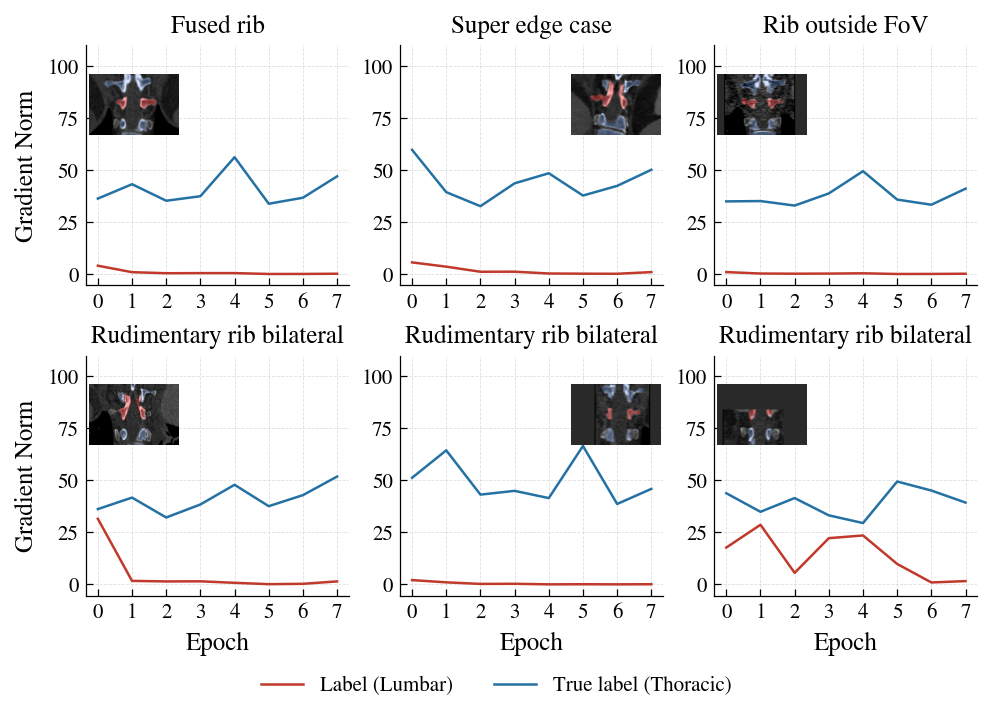

In [ ]:
# ── Score 8: difficult/ambiguous cases vs rudimentary rib bilateral (SR bds) ──
_anom2 = pd.read_excel(IN_OLD_GT_XLSX)
_anom2["scan_base"] = _anom2["fid"]
_anom2_best = _anom2.drop_duplicates("scan_base")

missed8 = t13_scores[
    (t13_scores[INT_SCORE] == 8) & t13_scores["patch_path"].notna()
].copy()
missed8["scan_base"] = missed8["sample_id"].str.replace(r"_vert\d+$", "", regex=True)
missed8 = missed8.merge(_anom2_best[["scan_base", "HE Comment"]], on="scan_base", how="left")

def _cat2(c):
    if pd.isna(c): return "Not annotated"
    c = str(c)
    if "SUPER EDGE CASE" in c: return "Super edge case"
    if "Type 4"          in c: return "Fused rib"
    if "abgeschnitten"   in c: return "Rib outside FoV"
    if "bleibt T12"      in c: return "Rib seen, kept as T12"
    if "bds"             in c: return "Rudimentary rib bilateral"
    if "SR"              in c: return "SR l/r"
    return "Not annotated"

missed8["category"] = missed8["HE Comment"].apply(_cat2)
print(missed8["category"].value_counts().to_string())

# ── Row 1: one fused rib, one super edge case, one rib outside FoV ────────────
row1_cats = ["Fused rib", "Super edge case", "Rib outside FoV"]
row1 = []
for cat in row1_cats:
    sub = missed8[missed8["category"] == cat]
    if len(sub):
        row1.append((sub.iloc[0], cat))
    else:
        print(f"WARNING: no sample for {cat!r}")

# ── Row 2: three SR bds samples ───────────────────────────────────────────────
sr_bds = missed8[missed8["category"] == "Rudimentary rib bilateral"].iloc[17:20].reset_index(drop=True)
row2    = [(sr_bds.iloc[i], "Rudimentary rib bilateral") for i in range(len(sr_bds))]

GROUPS2 = [
    (row1, "Ambiguous cases (score 8)"),
    (row2, "Rudimentary rib bilateral — SR bds (score 8)"),
]

_COL_LABEL2 = "#D55E00"  # Okabe-Ito Vermillion/orange
_COL_TRUE2  = "#009E73"  # Okabe-Ito Bluish Green
_INSET_W2, _INSET_H2 = 0.34, 0.47

fig, axes = plt.subplots(2, 3, figsize=plotstyle.figsize(1.0, 0.72))

for row_i, (row_samples, _) in enumerate(GROUPS2):
    for col_i in range(3):
        ax = axes[row_i, col_i]
        if col_i >= len(row_samples):
            ax.axis("off")
            continue

        r, cat_label = row_samples[col_i]
        sid       = r["sample_id"]

        try:
            norms = get_epoch_norms(sid)
        except Exception as e:
            ax.text(0.5, 0.5, f"No data\n{e}", ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        epochs = np.arange(N_EP)

        ax.plot(epochs, norms[:, ASSIGNED_CLS], color=_COL_LABEL2,
                label=f"Label ({CLS_NAMES[ASSIGNED_CLS]})")
        ax.plot(epochs, norms[:, TRUE_CLS], color=_COL_TRUE2,
                label=f"True label ({CLS_NAMES[TRUE_CLS]})")

        ax.set_title(cat_label, color="black")
        ax.set_xticks(epochs)
        ax.set_ylim(-0.05 * 110, 110)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(colors="black")

        if col_i == 0:
            ax.set_ylabel("Gradient Norm", color="black")
        if row_i == 1:
            ax.set_xlabel("Epoch", color="black")

        try:
            disk_v_inset = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
            slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v_inset, "coronal")
            inset = ax.inset_axes([1 - 0.01 - _INSET_W2, 1 - _INSET_H2, _INSET_W2, _INSET_H2])
            inset.imshow(slc, cmap="gray", origin="lower")
            inset.imshow(overlay, origin="lower")
            inset.axis("off")
        except Exception:
            pass

fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="outside lower center", ncol=2)
plotstyle.savefig(fig, "fig6_16_T13_score8_comparison")
plt.show()


#### Setup F: no-LO run, local notebook (`evaluation/evaluation_script_lisa.ipynb`)

In [ ]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   # thesis style on a clean rcParams state


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [ ]:
if not IN_CT_DIR.exists():
    raise RuntimeError(
        f"CT crops not found at {IN_CT_DIR}. "
        "Set MISLABELDET_DATASET_DIR to your prepared/ directory. "
        "These figures require the CT data (74 GB, not shipped with the repo)."
    )

import json
import re
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)

REPO = IN_REPO
sys.path.insert(0, str(REPO))
from evaluation.evaluate_run import (confidence_scores, expected_recall_at, glare_scores,  # noqa: E402
                                     metrics_for, to_tensor)
from helper import paths                                                                 # noqa: E402
from helper.last_layer import last_layer_grad_norms, load_confidence_dir                 # noqa: E402

RUN_DIR   = IN_NOLO_RUN_DIR
WEIGHTS_DIR = IN_NOLO_WEIGHTS  # training run behind RUN_DIR
CONF_DIR    = RUN_DIR / "confidence"                  # run_confidence.py output (condor/confidence.sub, CKPTS=all)
DATA_DIR    = IN_CT_DIR   # .npz crops (fast NFS server)
GT_XLSX     = IN_GT_XLSX
OLD_GT_XLSX = IN_OLD_GT_XLSX   # only for per-case radiologist annotations
FIG_DIR   = OUT_FIG_DIR
SAVE_FIGS = True

MISLABELS_CSV = IN_NOLO_CSV
GRAD_NORMS    = IN_NOLO_GRAD_NORMS
RUN_NAME      = RUN_DIR.name
REGIONS       = ["Cervical", "Thoracic", "Lumbar", "Sacral"]   # label 0..3

# Colorblind-safe pair / order (validated; the old green/red pair failed for deuteranopes)
C_CLEAN, C_MIS = "#0072B2", "#D55E00"
SERIES = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9"]   # Okabe–Ito
GRAY   = "#898781"

plt.rcParams.update({   # fonts and sizes come from lisathesis.mplstyle; this notebook's grid and spines stay
    "axes.grid": True, "grid.linestyle": "--", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    if SAVE_FIGS:
        plotstyle.savefig(fig, name)


In [ ]:
# ── Load scores + ground truth ────────────────────────────────────────────────
scores_df = pd.read_csv(MISLABELS_CSV)
scores_df["glare_score"]  = scores_df["glare score"]
scores_df["glarex_score"] = scores_df["glarex score"]

grad_norms = pd.read_pickle(GRAD_NORMS)
MAX_SCORE  = grad_norms["epoch"].nunique()          # = number of checkpoints
assert scores_df["glare_score"].max() <= MAX_SCORE

df_gt = pd.read_excel(GT_XLSX)
df_gt["true_label"] = df_gt["true_class"].map(REGIONS.index)
scores_df = scores_df.merge(
    df_gt[["sample_id", "vert_id", "anomaly_type", "source", "true_label"]],
    left_on="id", right_on="sample_id", how="left").drop(columns="sample_id")
scores_df[["vert_id", "true_label"]] = scores_df[["vert_id", "true_label"]].astype("Int64")
scores_df["mislabeled"] = scores_df["anomaly_type"].notna().astype(int)

# dsname for every sample (GT only has it for the positives)
filt = pd.read_excel(IN_FILTER_XLSX, usecols=["pid", "dsname"]).drop_duplicates("pid").set_index("pid")["dsname"]
scores_df["pid"]    = scores_df["id"].str.replace(r"_vert\d+$", "", regex=True)
scores_df["dsname"] = scores_df["pid"].map(filt)
assert scores_df["dsname"].notna().all()
assert (scores_df.set_index("id").loc[df_gt["sample_id"], "dsname"].values == df_gt["dsname"].values).all()

# Vectorised re-scoring (evaluation/evaluate_run.py) -- needed for truncation and baselines.
# Must reproduce the CSV written by merge_glare.py exactly.
norm_cols = [f"c{c}_grad_norm" for c in range(len(REGIONS))]
ids, labels, V = to_tensor(grad_norms, norm_cols)          # V: (n_samples, n_ckpt, n_classes)
G = glare_scores(V, labels)
scores_df = scores_df.set_index("id").loc[ids].reset_index()   # same row order as V from here on
assert (G["glare"] == scores_df["glare_score"].values).all()
assert np.allclose(G["glarex"], scores_df["glarex_score"].values, atol=1e-6)
scores_df["margin"]    = G["margin"]
scores_df["alt_label"] = G["alt_idx"]                     # suggested class = best alternative by GLAREx

n_found = scores_df["mislabeled"].sum()
print(f"{RUN_NAME}: {len(scores_df):,} samples, {MAX_SCORE} checkpoints")
print(f"GT mislabels present in this run: {n_found} / {len(df_gt)}")
missing = set(df_gt["sample_id"]) - set(scores_df["id"])
if missing:
    print("  not in run:", sorted(missing))


19-08-26_21:11_ep-8_single-gpu: 19,266 samples, 8 checkpoints
GT mislabels present in this run: 109 / 109


In [ ]:
scores_df["flagged"] = scores_df["glare_score"] < MAX_SCORE
g = scores_df.assign(tp=scores_df["flagged"] & (scores_df["mislabeled"] == 1),
                     fp=scores_df["flagged"] & (scores_df["mislabeled"] == 0)).groupby("dsname")
per_ds = pd.DataFrame({"samples": g.size(), "gt_mislabels": g["mislabeled"].sum(), "found": g["tp"].sum(),
                       "flagged": g["flagged"].sum(), "fp": g["fp"].sum()})
per_ds["recall"]    = per_ds["found"] / per_ds["gt_mislabels"]
per_ds["flag_rate"] = per_ds["flagged"] / per_ds["samples"]
per_ds["fpr"]       = per_ds["fp"] / (per_ds["samples"] - per_ds["gt_mislabels"])
per_ds = per_ds.sort_values("gt_mislabels", ascending=False)
per_ds.style.format({"recall": "{:.0%}", "flag_rate": "{:.2%}", "fpr": "{:.2%}"}, na_rep="–")


,samples,gt_mislabels,found,flagged,fp,recall,flag_rate,fpr
dsname,,,,,,,,
dataset-sagthomas,5701,38,34,475,441,89%,8.33%,7.79%
dataset-verse20,811,21,20,72,52,95%,8.88%,6.58%
dataset-ctfu1org,4342,20,17,275,258,85%,6.33%,5.97%
dataset-fxclass,2212,16,12,179,167,75%,8.09%,7.60%
dataset-ced,873,8,6,93,87,75%,10.65%,10.06%
dataset-ATL,1869,3,3,113,110,100%,6.05%,5.89%
dataset-CTSp1k,858,2,1,32,31,50%,3.73%,3.62%
dataset-CSIsegment,210,1,1,11,10,100%,5.24%,4.78%
dataset-CSILabel,658,0,0,41,41,–,6.23%,6.23%


In [ ]:
def plot_confusion(ax, rows, cols, row_name, title):
    K = len(REGIONS)
    cm = pd.crosstab(rows, cols).reindex(index=range(K), columns=range(K), fill_value=0).values
    share = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax.imshow(share, cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("oi_blue", ["#FFFFFF", "#0072B2"]),
              vmin=0, vmax=1)
    for i in range(K):
        for j in range(K):
            if cm[i, j]:
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=11,
                        color="white" if share[i, j] > 0.55 else "#0b0b0b")
    ax.set(xticks=range(K), yticks=range(K), xticklabels=REGIONS, yticklabels=REGIONS,
           xlabel="Suggested class", ylabel=row_name, title=title)
    ax.grid(False)


### Figure 6.17: True class vs. GLARE's suggested alternative class (GLAREx) for all 101 ground-truth mislabels in the updated dataset.


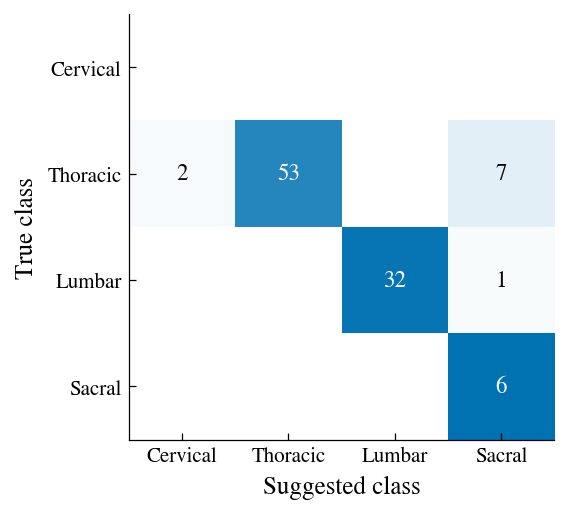

correct suggestion, all GT mislabels: 91/101  (flagged 63/65, never flagged 28/36)
of which L1→T13 with GLARE score 8: 27/34 suggested Thoracic


In [ ]:
# Fig 6.17 (user round 8): all ground-truth mislabels of the LO run (same run and 101-row ground truth as
# Figs 6.11-6.13), true class vs. the class GLARE suggests. The source cell (evaluation_script_lisa.ipynb cell 21)
# drew the same matrix for the 109 GT mislabels of the no-LO run.
# Suggested class = best alternative by GLAREx (exists for every sample, flagged or not). With GLARE score 8 every
# other class won 0 epochs, so there only the GLAREx tie-break carries information.
lo_scores = pd.read_csv(IN_LO_CSV)
lo_gt     = pd.read_excel(IN_GT_LO_XLSX)
gt_all = lo_gt.merge(lo_scores, left_on="sample_id", right_on="id", validate="one_to_one")
assert len(gt_all) == len(lo_gt), "GT ids missing from the LO run"
true_idx = gt_all["true_class"].map(REGIONS.index)
alt_idx  = gt_all["alternative class (glarex)"].astype(int)

fig, ax = plt.subplots(figsize=plotstyle.figsize(0.6, 0.85))
plot_confusion(ax, true_idx, alt_idx, "True class", None)   # no title (user round 7)
save(fig, "fig6_17_confusion_suggested_all_gt_LO")
plt.show()
ok      = alt_idx == true_idx
flagged = gt_all["glare score"] < 8                          # strict threshold, 8 checkpoints
print(f"correct suggestion, all GT mislabels: {ok.sum()}/{len(gt_all)}  "
      f"(flagged {ok[flagged].sum()}/{flagged.sum()}, never flagged {ok[~flagged].sum()}/{(~flagged).sum()})")
t13_8 = (gt_all["anomaly_type"] == "T13_extra") & (gt_all["vert_id"] == 20) & (gt_all["glare score"] == 8)
print(f"of which L1→T13 with GLARE score 8: {ok[t13_8].sum()}/{t13_8.sum()} suggested Thoracic")


### Figure 6.18: Comparison of GLARE and GLAREx with established mislabel detection methods. Training samples are ranked by each method's score, and recall (left) and F1 score (right) are shown as a function of the fraction of training data checked. TracIn is evaluated with gradients of all parameters (solid) and of the last layer only (dashed). All scores are computed post hoc on the same training runs and checkpoints.



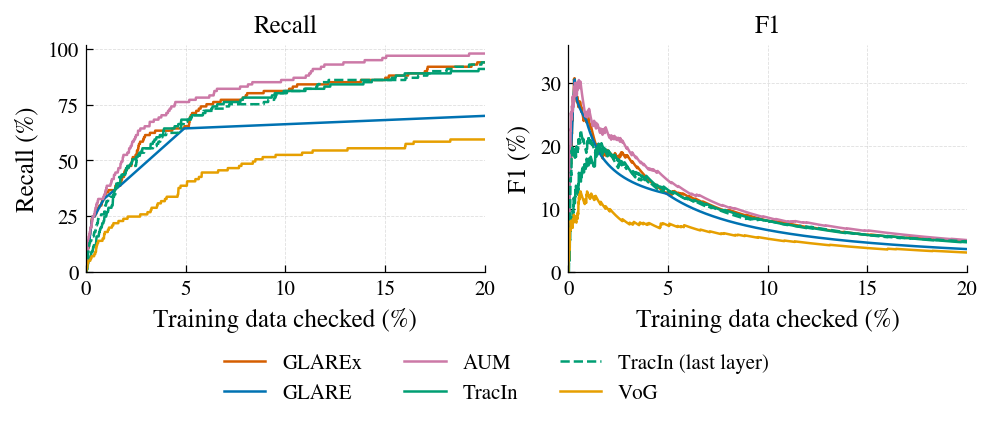

In [ ]:
# ── LO-8 run: recall and F1 vs. fraction checked, GLARE vs. AUM / TracIn / VoG ──
LO_RUN      = "label_override_8ep_23092026_2135"
LO_EVAL_DIR = IN_LO_BASELINES_XLSX.parent
LO_XLSX     = IN_LO_BASELINES_XLSX      # md5 e353f3b7...
ranked = pd.read_excel(LO_XLSX, sheet_name="real_ranked")          # one row per sample, y = GT mislabel

# scorer column → (label, colour, line style); all oriented lower = more suspicious
LO_SCORERS = {"glarex":    ("GLAREx",              "#D55E00", "-"),
              "glare":     ("GLARE",               "#0072B2", "-"),
              "aum":       ("AUM",                 "#CC79A7", "-"),
              "tracin":    ("TracIn",              "#009E73", "-"),
              "tracin_ll": ("TracIn (last layer)", "#009E73", "--"),
              "vog":       ("VoG",                 "#E69F00", "-"),
              #"conf_p":    ("conf_p",              "#e87ba4", "--")
              }
TABLE_FRACS = [0.005, 0.01, 0.02, 0.05, 0.10]
X_MAX_LO    = 20                                                    # % of training data, as in the thesis tables

y_lo = ranked["y"].to_numpy()
n_lo, P_lo = len(y_lo), int(y_lo.sum())
k_lo = np.arange(1, n_lo + 1)
x_lo = 100 * k_lo / n_lo

def expected_tp_curve(s, y):
    """Expected TP(k) for k = 1..n under uniformly random tie-breaking: exact cumulative TP at the end of
    each block of tied scores, linear in between (vectorised evaluate_run.expected_recall_at)."""
    order = np.argsort(s, kind="mergesort")
    ss, yy = s[order], y[order]
    ends = np.r_[np.nonzero(np.diff(ss))[0], len(ss) - 1]           # last index of every tie block
    return np.interp(np.arange(1, len(s) + 1), np.r_[0, ends + 1], np.r_[0, np.cumsum(yy)[ends]])

curves = {}
for col in LO_SCORERS:
    tp = expected_tp_curve(ranked[col].to_numpy(dtype=float), y_lo)
    curves[col] = {"recall": 100 * tp / P_lo, "f1": 100 * 2 * tp / (k_lo + P_lo)}   # F1 = 2PR/(P+R) = 2TP/(k+P)

fig, (axL, axR) = plt.subplots(1, 2, figsize=plotstyle.figsize(1.0, 0.42), sharex=True)
for col, (label, color, ls) in LO_SCORERS.items():
    axL.plot(x_lo, curves[col]["recall"], color=color, ls=ls, label=label)
    axR.plot(x_lo, curves[col]["f1"], color=color, ls=ls)
#axL.plot(x_lo, np.minimum(x_lo, 100), color=GRAY, lw=1, ls=":", label="random")
#axL.plot(x_lo, 100 * np.minimum(1, k_lo / P_lo), color=GRAY, lw=1, ls="-.", label="oracle")
#axR.plot(x_lo, 100 * 2 * np.minimum(k_lo, P_lo) / (k_lo + P_lo), color=GRAY, lw=1, ls="-.")
for ax, ylabel in [(axL, f"Recall ({PCT})"), (axR, f"F1 ({PCT})")]:
    for f in TABLE_FRACS:
        #ax.axvline(100 * f, color="#c3c2b7", lw=0.8, zorder=0)
        continue
    ax.set(xlim=(0, X_MAX_LO), xlabel=f"Training data checked ({PCT})", ylabel=ylabel)
axL.set(ylim=(0, 102))
axR.set(ylim=(0, 36))
axL.set_title("Recall")
axR.set_title("F1")
fig.legend(*axL.get_legend_handles_labels(), loc="outside lower center", ncol=3)
#fig.suptitle(f"{LO_RUN}  ·  {P_lo} GT mislabels among {n_lo:,} samples", fontsize=12)
if SAVE_FIGS:
    plotstyle.savefig(fig, f"fig6_18_recall_f1_vs_fraction_{LO_RUN}")
plt.show()

# values at the table fractions (k = round(frac * n), as in evaluate_run)
ks = [int(round(f * n_lo)) for f in TABLE_FRACS]
lo_table = pd.DataFrame({(m, f"{100 * f:g} %"): [curves[c][m][k - 1] for c in LO_SCORERS]
                         for m in ("recall", "f1") for f, k in zip(TABLE_FRACS, ks)},
                        index=[v[0] for v in LO_SCORERS.values()])
lo_table.style.format("{:.1f}").set_caption("Recall / F1 (%) at the table fractions, ties broken in expectation")


## Appendix

#### Setup E (again): T13 analysis, LO run

In [ ]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   # thesis style on a clean rcParams state


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [ ]:
if not IN_CT_DIR.exists():
    raise RuntimeError(
        f"CT crops not found at {IN_CT_DIR}. "
        "Set MISLABELDET_DATASET_DIR to your prepared/ directory. "
        "These figures require the CT data (74 GB, not shipped with the repo)."
    )

import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
GLARE_CSV   = IN_LO_CSV
GT_CSV      = IN_GT_DERIVED_CSV
FILTER_XLS  = IN_FILTER_XLSX
SPEC_PATH   = IN_LO_SPEC
PREPARED    = IN_CT_DIR

SCORE_COL   = "glarex score"   # continuous score column
INT_SCORE   = "glare score"    # integer 0-8


In [ ]:
# ── Load GLARE scores ──────────────────────────────────────────────────────────
scores = pd.read_csv(GLARE_CSV)
scores = scores.rename(columns={"id": "sample_id"})

# ── Load GT mislabels — T13_extra vert20 only ─────────────────────────────────
gt = pd.read_csv(GT_CSV)
t13 = gt[(gt["anomaly_type"] == "T13_extra") & (gt["vert_id"] == 20)].copy()

# ── Merge scores with T13 GT ──────────────────────────────────────────────────
t13_scores = scores.merge(t13[["sample_id","pid","dsname","vert_id","source","disk_vert_id"]],
                          on="sample_id", how="inner")
print(f"GLARE total samples    : {len(scores)}")
print(f"T13 vert20 in GT       : {len(t13)}")
print(f"T13 vert20 in GLARE    : {len(t13_scores)}")
print()
print("Integer GLARE score distribution for T13 vert20 mislabels:")
print(t13_scores[INT_SCORE].value_counts().sort_index().to_string())


GLARE total samples    : 19266
T13 vert20 in GT       : 62
T13 vert20 in GLARE    : 62

Integer GLARE score distribution for T13 vert20 mislabels:
glare score
0     3
1     2
2     1
3     2
5     2
6     5
7    13
8    34


In [ ]:
# ── Build sample_id → file path mapping ───────────────────────────────────────
# File format: {PREPARED}/{dsname}/{split}/segment0.8mm_vert{disk_vert}_sub-{pid}.npz
# The disk_vert (orig vert in file name) differs from training_vert for Rule A/B PIDs.
# We invert pid_corrections to get disk_vert from training_vert.

with open(SPEC_PATH) as f:
    spec = json.load(f)
pid_fix_1820 = set(spec.get("pid_fix_1820", []))
pid_fix_28   = set(spec.get("pid_fix_28",   []))

fdf = pd.read_excel(FILTER_XLS)
fdf = fdf[(fdf["has_T1"]==1) & (fdf["is_consecutive"]==1)]
pid_meta = {
    str(r["pid"]).strip(): {
        "dsname": str(r["dsname"]).strip(),
        "split":  str(r["split"]).strip(),
        "disk_verts": set(int(v) for v in ast.literal_eval(str(r["vert_label"]))
                          if pd.notna(v)),
    }
    for _, r in fdf.iterrows()
}

def apply_rules(verts):
    if 28 in verts and 20 in verts:
        return {v: (20 if v==28 else (v+1 if v>=20 else v)) for v in verts}
    if 20 in verts and 19 not in verts and 18 in verts:
        return {v: (v-1 if v>=20 else v) for v in verts}
    return {v: v for v in verts}

# Build inv_corrections: {pid: {training_vert: disk_vert}}
inv_corrections = {}
for pid in pid_fix_1820 | pid_fix_28:
    if pid in pid_meta:
        corr = apply_rules(pid_meta[pid]["disk_verts"])
        inv_corrections[pid] = {tv: dv for dv, tv in corr.items()}

# Also handle LO PIDs via disk_vert_id in the GT table (already stored there)

def get_patch_path(pid, training_vert, dsname=None, split=None, disk_vert_id=None):
    """Resolve npz path for a training sample."""
    if pid not in pid_meta:
        return None
    meta  = pid_meta[pid]
    dname = dsname or meta["dsname"]
    spl   = split  or meta["split"]
    # disk_vert: use GT-provided disk_vert_id if available, else invert corrections
    if disk_vert_id and not pd.isna(disk_vert_id):
        disk_v = int(disk_vert_id)
    else:
        inv = inv_corrections.get(pid, {})
        disk_v = inv.get(training_vert, training_vert)
    path = PREPARED / dname / spl / f"segment0.8mm_vert{disk_v}_sub-{pid}.npz"
    return path if path.exists() else None

# Attach file paths to t13_scores
t13_scores["patch_path"] = t13_scores.apply(
    lambda r: get_patch_path(r["pid"], r["vert_id"], r["dsname"], disk_vert_id=r["disk_vert_id"]),
    axis=1
)
found = t13_scores["patch_path"].notna().sum()
print(f"Patch files found: {found} / {len(t13_scores)}")


Patch files found: 62 / 62


In [ ]:
# ── Patch loading helpers ──────────────────────────────────────────────────────
def load_mid_slice(path, view="sagittal"):
    """Load central 2-D slice from a 3-D CT patch (H×W×D).
    view: 'sagittal'=axis 0, 'coronal'=axis 1, 'axial'=axis 2
    """
    d    = np.load(path, allow_pickle=True)
    img  = d["img"].astype(np.float32)
    axis = {"sagittal": 0, "coronal": 1, "axial": 2}[view]
    mid  = img.shape[axis] // 2
    slc  = np.take(img, mid, axis=axis)
    slc  = np.clip(slc, -200, 1000)
    slc  = (slc + 200) / 1200
    return slc

def load_mid_slice_with_mask(path, target_vert_id, view="coronal", alpha=0.35):
    """Load central slice and return (img_slice, overlay_rgba) where the
    target vertebra is highlighted in red and others in blue."""
    d    = np.load(path, allow_pickle=True)
    img  = d["img"].astype(np.float32)
    msk  = d["msk"]
    axis = {"sagittal": 0, "coronal": 1, "axial": 2}[view]
    mid  = img.shape[axis] // 2
    img_slc = np.take(img, mid, axis=axis)
    msk_slc = np.take(msk, mid, axis=axis)
    img_slc = np.clip(img_slc, -200, 1000)
    img_slc = (img_slc + 200) / 1200

    H, W = img_slc.shape
    overlay = np.zeros((H, W, 4), dtype=np.float32)
    # target vertebra: red
    target_mask = msk_slc == target_vert_id
    overlay[target_mask] = [1.0, 0.1, 0.1, alpha]
    # other vertebrae: blue
    other_mask = (msk_slc > 0) & ~target_mask
    overlay[other_mask] = [0.1, 0.4, 1.0, alpha * 0.5]
    return img_slc, overlay


In [ ]:
import pickle

GN_PKL = IN_LO_GRAD_NORMS
_gn = pickle.load(open(GN_PKL, "rb"))

N_EP         = 8
CLS_NAMES    = {0: "Cervical", 1: "Thoracic", 2: "Lumbar", 3: "Sacral"}
ASSIGNED_CLS = 2   # Lumbar (wrong label for T13)
TRUE_CLS     = 1   # Thoracic (correct class)

def get_epoch_norms(sample_id):
    rows = _gn[_gn["id"] == sample_id].sort_values("epoch")
    return rows[["c0_grad_norm", "c1_grad_norm", "c2_grad_norm", "c3_grad_norm"]].values


### Figure A.1: Comparison of gradient norms between T13 TEA samples of different GLARE scores.



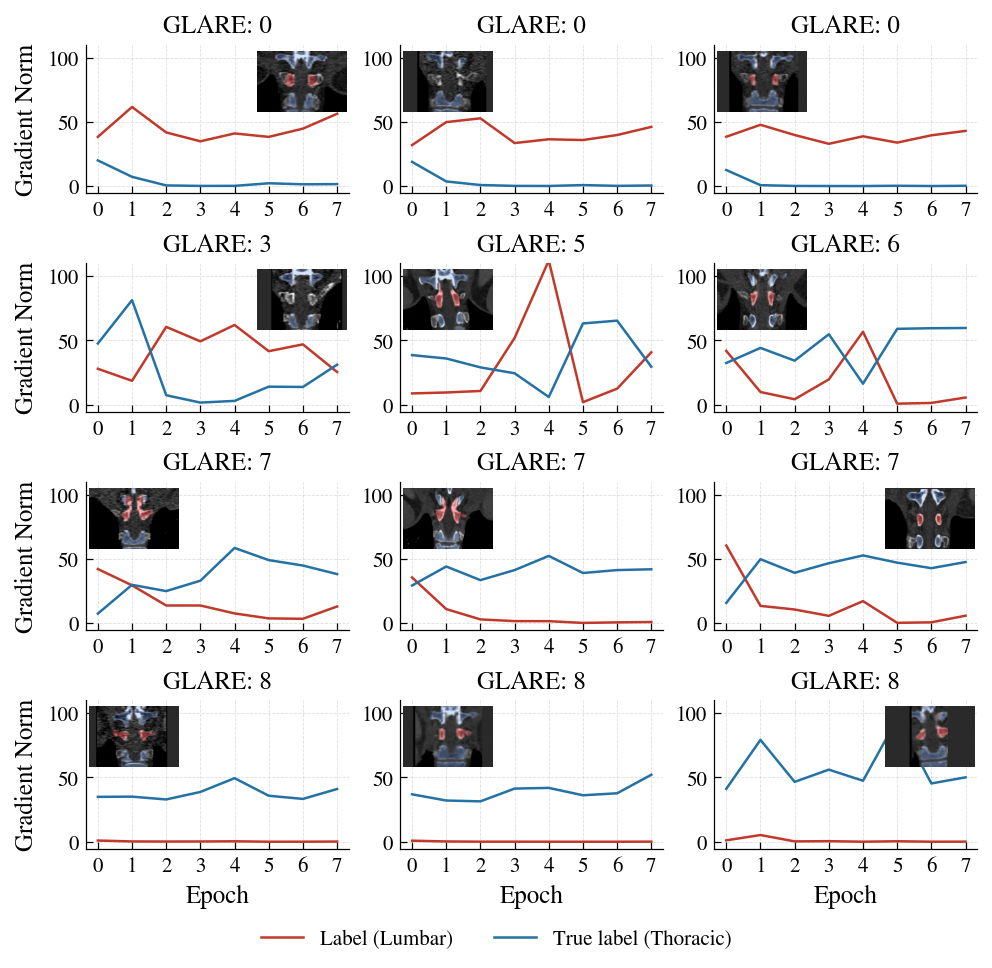

Sample IDs used:
  Detected (score 0–1): ['fxclass0137_dir-sag_sequ-WS30MPR4_vert20', 'ctfu00610_ses-20091111_ce-pv_vert20', 'ID0089_ses-24112010_ce-pv_vert20']
  Borderline (score 3–6): ['ctfu00897_ses-20170303_ce-art_vert20', 'verse601_vert20', 'verse599_dir-iso_vert20']
  Missed (score 7): ['ATL211_dir-sag_vert20', 'verse576_vert20', 'ctfu00509_ses-20060725_ce-pv_vert20']
  Missed (score 8): ['ctfu00544_ses-20140612_ce-pv_vert20', 'ID0260_ses-14092007_ce-pv_vert20', 'ctfu00469_ses-20070904_ce-pv_vert20']


In [ ]:
# ── Sample selection ───────────────────────────────────────────────────────────
_v = t13_scores[t13_scores["patch_path"].notna()].copy()

NCOLS = 3

grp_low    = _v[_v[INT_SCORE].isin([0, 1])].sort_values(INT_SCORE).head(3).reset_index(drop=True)
grp_mid    = pd.concat([
    _v[_v[INT_SCORE] == s].iloc[[0]]
    for s in [3, 5, 6] if (_v[INT_SCORE] == s).any()
]).head(3).reset_index(drop=True)
grp_high7  = _v[_v[INT_SCORE] == 7].head(3).reset_index(drop=True)
# SR bds category for score-8 row
_anom_m = pd.read_excel(IN_OLD_GT_XLSX)
_anom_m["scan_base"] = _anom_m["fid"]
_anom_m_best = _anom_m.drop_duplicates("scan_base")
_v_cat = _v.copy()
_v_cat["scan_base"] = _v_cat["sample_id"].str.replace(r"_vert\d+$", "", regex=True)
_v_cat = _v_cat.merge(_anom_m_best[["scan_base", "HE Comment"]], on="scan_base", how="left")
grp_high8 = (
    _v_cat[(_v_cat[INT_SCORE] == 8) &
           _v_cat["HE Comment"].apply(lambda c: pd.notna(c) and "bds" in str(c))]
    .head(3).reset_index(drop=True)
)

GROUPS = [
    (grp_low,   "Detected (score 0–1)"),
    (grp_mid,   "Borderline (score 3–6)"),
    (grp_high7, "Missed (score 7)"),
    (grp_high8, "Missed (score 8)"),
]

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(GROUPS), NCOLS, figsize=plotstyle.figsize(1.0, 0.98))

for row_i, (grp, row_label) in enumerate(GROUPS):
    for col_i in range(NCOLS):
        ax = axes[row_i, col_i]

        if col_i >= len(grp):
            ax.axis("off")
            continue

        r         = grp.iloc[col_i]
        sid       = r["sample_id"]
        score_int = int(r[INT_SCORE])

        try:
            norms = get_epoch_norms(sid)
        except Exception as e:
            ax.text(0.5, 0.5, f"No data\n{e}", ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        epochs = np.arange(N_EP)

        # Assigned label — red solid
        ax.plot(epochs, norms[:, ASSIGNED_CLS],
                color="#C0392B",
                label=f"Label ({CLS_NAMES[ASSIGNED_CLS]})")

        # True label — green solid
        ax.plot(epochs, norms[:, TRUE_CLS],
                color="#2471A3",
                label=f"True label ({CLS_NAMES[TRUE_CLS]})")


        ax.set_title(f"GLARE: {score_int}", color="black")
        ax.set_xticks(epochs)
        ax.set_ylim(-0.05 * 110, 110)   # 5 % margin below 0 like the x-axis, so zero gradients stay visible
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(colors="black")

        if col_i == 0:
            ax.set_ylabel("Gradient Norm", color="black")
        if row_i == len(GROUPS) - 1:
            ax.set_xlabel("Epoch", color="black")

        # ── coronal CT inset with segmentation mask ───────────────────────────
        try:
            disk_v_inset = int(r["disk_vert_id"]) if pd.notna(r["disk_vert_id"]) else int(r["vert_id"])
            slc, overlay = load_mid_slice_with_mask(r["patch_path"], disk_v_inset, "coronal")
            inset = ax.inset_axes(plotstyle.inset_box(ax, 0.34, 0.47))   # top left, or top right if the curves run there
            inset.imshow(slc, cmap="gray", origin="lower")
            inset.imshow(overlay, origin="lower")
            inset.axis("off")
        except Exception:
            pass

fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="outside lower center", ncol=2)
plotstyle.savefig(fig, "figA_1_T13_grad_norm_curves_3groups")
plt.show()

print("Sample IDs used:")
for grp, label in GROUPS:
    print(f"  {label}: {grp['sample_id'].tolist()}")


#### Setup F (again): local notebook; Figs A.2/A.3 also use `ranked` from the Fig 6.18 cell

In [ ]:
import matplotlib.pyplot as plt
import plotstyle
plt.rcdefaults()
plotstyle.use()   # thesis style on a clean rcParams state


/home/student/lisa_ma/evaluation/plotstyle.py:20: UserWarning: LaTeX not found - falling back to STIX fonts. Figures will NOT exactly match the thesis font.
  warnings.warn("LaTeX not found - falling back to STIX fonts. "


In [ ]:
if not IN_CT_DIR.exists():
    raise RuntimeError(
        f"CT crops not found at {IN_CT_DIR}. "
        "Set MISLABELDET_DATASET_DIR to your prepared/ directory. "
        "These figures require the CT data (74 GB, not shipped with the repo)."
    )

import json
import re
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score)

REPO = IN_REPO
sys.path.insert(0, str(REPO))
from evaluation.evaluate_run import (confidence_scores, expected_recall_at, glare_scores,  # noqa: E402
                                     metrics_for, to_tensor)
from helper import paths                                                                 # noqa: E402
from helper.last_layer import last_layer_grad_norms, load_confidence_dir                 # noqa: E402

RUN_DIR   = IN_NOLO_RUN_DIR
WEIGHTS_DIR = IN_NOLO_WEIGHTS  # training run behind RUN_DIR
CONF_DIR    = RUN_DIR / "confidence"                  # run_confidence.py output (condor/confidence.sub, CKPTS=all)
DATA_DIR    = IN_CT_DIR   # .npz crops (fast NFS server)
GT_XLSX     = IN_GT_XLSX
OLD_GT_XLSX = IN_OLD_GT_XLSX   # only for per-case radiologist annotations
FIG_DIR   = OUT_FIG_DIR
SAVE_FIGS = True

MISLABELS_CSV = IN_NOLO_CSV
GRAD_NORMS    = IN_NOLO_GRAD_NORMS
RUN_NAME      = RUN_DIR.name
REGIONS       = ["Cervical", "Thoracic", "Lumbar", "Sacral"]   # label 0..3

# Colorblind-safe pair / order (validated; the old green/red pair failed for deuteranopes)
C_CLEAN, C_MIS = "#0072B2", "#D55E00"
SERIES = ["#0072B2", "#D55E00", "#009E73", "#E69F00", "#CC79A7", "#56B4E9"]   # Okabe–Ito
GRAY   = "#898781"

plt.rcParams.update({   # fonts and sizes come from lisathesis.mplstyle; this notebook's grid and spines stay
    "axes.grid": True, "grid.linestyle": "--", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

def save(fig, name):
    if SAVE_FIGS:
        plotstyle.savefig(fig, name)


In [ ]:
# ── Load scores + ground truth ────────────────────────────────────────────────
scores_df = pd.read_csv(MISLABELS_CSV)
scores_df["glare_score"]  = scores_df["glare score"]
scores_df["glarex_score"] = scores_df["glarex score"]

grad_norms = pd.read_pickle(GRAD_NORMS)
MAX_SCORE  = grad_norms["epoch"].nunique()          # = number of checkpoints
assert scores_df["glare_score"].max() <= MAX_SCORE

df_gt = pd.read_excel(GT_XLSX)
df_gt["true_label"] = df_gt["true_class"].map(REGIONS.index)
scores_df = scores_df.merge(
    df_gt[["sample_id", "vert_id", "anomaly_type", "source", "true_label"]],
    left_on="id", right_on="sample_id", how="left").drop(columns="sample_id")
scores_df[["vert_id", "true_label"]] = scores_df[["vert_id", "true_label"]].astype("Int64")
scores_df["mislabeled"] = scores_df["anomaly_type"].notna().astype(int)

# dsname for every sample (GT only has it for the positives)
filt = pd.read_excel(IN_FILTER_XLSX, usecols=["pid", "dsname"]).drop_duplicates("pid").set_index("pid")["dsname"]
scores_df["pid"]    = scores_df["id"].str.replace(r"_vert\d+$", "", regex=True)
scores_df["dsname"] = scores_df["pid"].map(filt)
assert scores_df["dsname"].notna().all()
assert (scores_df.set_index("id").loc[df_gt["sample_id"], "dsname"].values == df_gt["dsname"].values).all()

# Vectorised re-scoring (evaluation/evaluate_run.py) -- needed for truncation and baselines.
# Must reproduce the CSV written by merge_glare.py exactly.
norm_cols = [f"c{c}_grad_norm" for c in range(len(REGIONS))]
ids, labels, V = to_tensor(grad_norms, norm_cols)          # V: (n_samples, n_ckpt, n_classes)
G = glare_scores(V, labels)
scores_df = scores_df.set_index("id").loc[ids].reset_index()   # same row order as V from here on
assert (G["glare"] == scores_df["glare_score"].values).all()
assert np.allclose(G["glarex"], scores_df["glarex_score"].values, atol=1e-6)
scores_df["margin"]    = G["margin"]
scores_df["alt_label"] = G["alt_idx"]                     # suggested class = best alternative by GLAREx

n_found = scores_df["mislabeled"].sum()
print(f"{RUN_NAME}: {len(scores_df):,} samples, {MAX_SCORE} checkpoints")
print(f"GT mislabels present in this run: {n_found} / {len(df_gt)}")
missing = set(df_gt["sample_id"]) - set(scores_df["id"])
if missing:
    print("  not in run:", sorted(missing))


19-08-26_21:11_ep-8_single-gpu: 19,266 samples, 8 checkpoints
GT mislabels present in this run: 109 / 109


In [ ]:
scores_df["flagged"] = scores_df["glare_score"] < MAX_SCORE
g = scores_df.assign(tp=scores_df["flagged"] & (scores_df["mislabeled"] == 1),
                     fp=scores_df["flagged"] & (scores_df["mislabeled"] == 0)).groupby("dsname")
per_ds = pd.DataFrame({"samples": g.size(), "gt_mislabels": g["mislabeled"].sum(), "found": g["tp"].sum(),
                       "flagged": g["flagged"].sum(), "fp": g["fp"].sum()})
per_ds["recall"]    = per_ds["found"] / per_ds["gt_mislabels"]
per_ds["flag_rate"] = per_ds["flagged"] / per_ds["samples"]
per_ds["fpr"]       = per_ds["fp"] / (per_ds["samples"] - per_ds["gt_mislabels"])
per_ds = per_ds.sort_values("gt_mislabels", ascending=False)
per_ds.style.format({"recall": "{:.0%}", "flag_rate": "{:.2%}", "fpr": "{:.2%}"}, na_rep="–")


,samples,gt_mislabels,found,flagged,fp,recall,flag_rate,fpr
dsname,,,,,,,,
dataset-sagthomas,5701,38,34,475,441,89%,8.33%,7.79%
dataset-verse20,811,21,20,72,52,95%,8.88%,6.58%
dataset-ctfu1org,4342,20,17,275,258,85%,6.33%,5.97%
dataset-fxclass,2212,16,12,179,167,75%,8.09%,7.60%
dataset-ced,873,8,6,93,87,75%,10.65%,10.06%
dataset-ATL,1869,3,3,113,110,100%,6.05%,5.89%
dataset-CTSp1k,858,2,1,32,31,50%,3.73%,3.62%
dataset-CSIsegment,210,1,1,11,10,100%,5.24%,4.78%
dataset-CSILabel,658,0,0,41,41,–,6.23%,6.23%


In [ ]:
def plot_confusion(ax, rows, cols, row_name, title):
    K = len(REGIONS)
    cm = pd.crosstab(rows, cols).reindex(index=range(K), columns=range(K), fill_value=0).values
    share = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    ax.imshow(share, cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list("oi_blue", ["#FFFFFF", "#0072B2"]),
              vmin=0, vmax=1)
    for i in range(K):
        for j in range(K):
            if cm[i, j]:
                ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=11,
                        color="white" if share[i, j] > 0.55 else "#0b0b0b")
    ax.set(xticks=range(K), yticks=range(K), xticklabels=REGIONS, yticklabels=REGIONS,
           xlabel="Suggested class", ylabel=row_name, title=title)
    ax.grid(False)


### Figure A.2 and A.3: A.2: Fraction of training data checked before each mislabeled sample of the TEA is found, per method. T12→L1 (n = 10) and L5→S1 (n = 6) are shown. Dashed lines mark the GLARE score thresholds. A.3: As Figure A.2 for the T13 enumeration anomaly: L1→T13 (n = 62) and S1→L5 (n = 23).


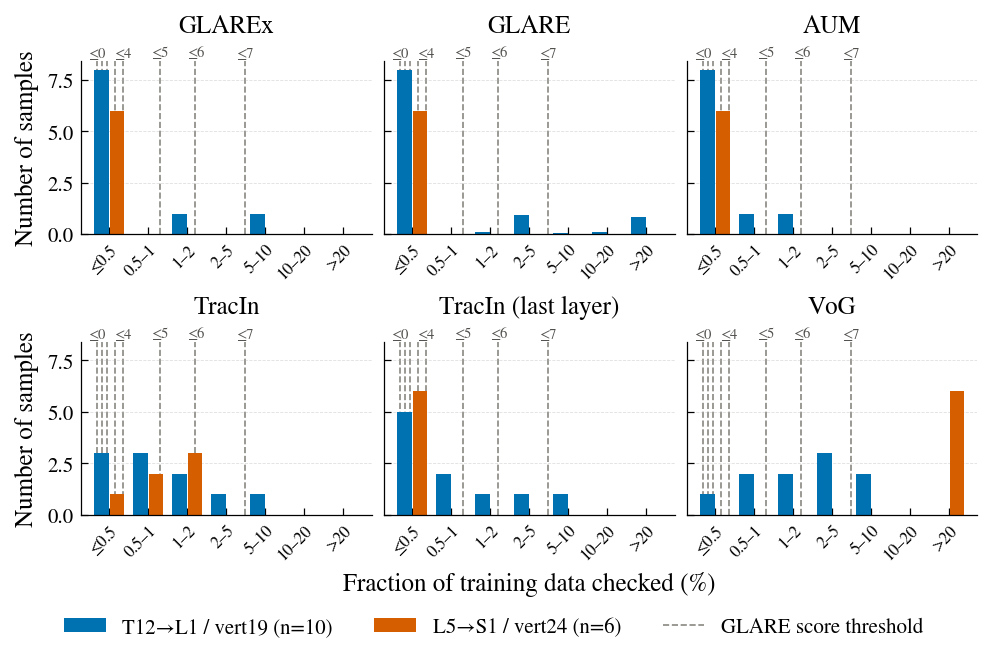

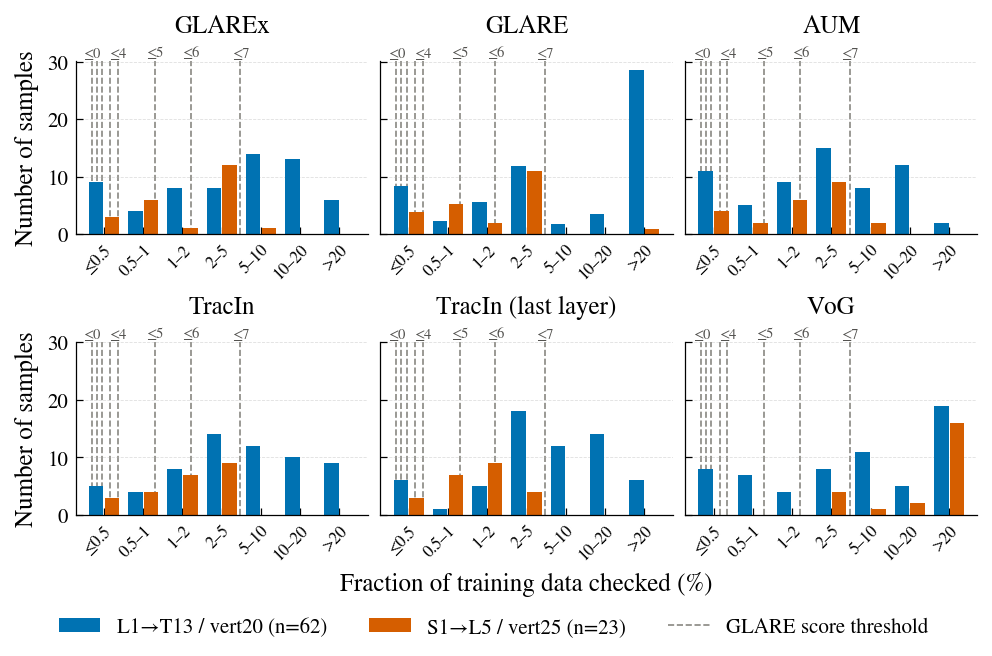

In [ ]:
# ── LO-8 run: per anomaly type, where in each method's ranking the mislabels land ──
gt_derived = pd.read_csv(IN_GT_DERIVED_CSV)
rk = ranked.merge(gt_derived[["sample_id", "anomaly_type", "vert_id"]], left_on="id", right_on="sample_id", how="left")
assert (rk["anomaly_type"].notna() == (rk["y"] == 1)).all(), "derived GT and y disagree"

RANK_FRACS  = [0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.20, 1.0]
RANK_LABELS = ["≤0.5", "0.5–1", "1–2", "2–5", "5–10", "10–20", ">20"]
k_edges = np.array([int(round(f * n_lo)) for f in RANK_FRACS])         # k = round(frac * n), as in evaluate_run

def expected_rank_bins(s, mask):
    """Expected number of `mask` samples per rank bin; a sample in a tie block spanning ranks (a, b] is spread
    uniformly over it (random tie-breaking)."""
    _, inv, cnt = np.unique(s, return_inverse=True, return_counts=True)
    start = np.r_[0, np.cumsum(cnt)[:-1]]
    a, b = start[inv][mask], (start + cnt)[inv][mask]
    ov = np.clip(np.minimum(b[:, None], k_edges[1:]) - np.maximum(a[:, None], k_edges[:-1]), 0, None)
    return (ov / (b - a)[:, None]).sum(axis=0)

# where GLARE's thresholds "score ≤ t" fall on the binned x-axis (linear inside each bin)
glare_scores_lo = ranked["glare"].to_numpy()
GLARE_T = range(int(glare_scores_lo.max()))                             # ≤ max is 100 %
glare_x = [np.interp((glare_scores_lo <= t).mean(), RANK_FRACS, np.arange(len(RANK_FRACS)) - 0.5) for t in GLARE_T]
GLARE_LABELED = {0, 4, 5, 6, 7}                                          # ≤1..≤3 sit on top of ≤0/≤4

fmt_n = lambda v: f"{v:.0f}" if abs(v - round(v)) < 0.05 else f"{v:.1f}"
ANOMALY_FIGS = [("T12 missing", "t12missing", [("T12_missing", 19, "T12→L1 / vert19"), ("T12_missing", 24, "L5→S1 / vert24")]),
                ("T13 extra",   "t13extra",   [("T13_extra", 20, "L1→T13 / vert20"), ("T13_extra", 25, "S1→L5 / vert25")])]
found_rows = []
for title, fname, groups in ANOMALY_FIGS:
    masks = [((rk["anomaly_type"] == at) & (rk["vert_id"] == v)).to_numpy() for at, v, _ in groups]
    ncols = 3 if len(LO_SCORERS) <= 6 else 4                             # grid follows LO_SCORERS
    nrows = int(np.ceil(len(LO_SCORERS) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=plotstyle.figsize(1.0, 0.66), sharex=True, sharey=True,
                            squeeze=False)
    xb, bar_w = np.arange(len(RANK_LABELS)), 0.4
    for ax, (col, (label, _, _)) in zip(axs.flat, LO_SCORERS.items()):
        s = ranked[col].to_numpy(dtype=float)
        for j, ((at, v, glabel), m) in enumerate(zip(groups, masks)):
            c = expected_rank_bins(s, m)
            ax.bar(xb + (j - 0.5) * bar_w, c, width=bar_w - 0.03, color=SERIES[j],
                   label=f"{glabel} (n={m.sum()})")
            found_rows.append({"anomaly": title, "group": glabel, "method": label, "n": int(m.sum()),
                               **{f"≤{RANK_LABELS[i].split('–')[-1].lstrip('≤')} %": c[:i + 1].sum() for i in range(6)}})
        for t, gx in zip(GLARE_T, glare_x):
            ax.axvline(gx, color=GRAY, lw=0.8, ls="--", zorder=0.5)       # full height, behind the bars
            if t in GLARE_LABELED:
                ax.text(gx, 1.01, f"≤{t}", transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                        fontsize=7, color="#52514e")
        ax.set_title(label, pad=14)                         # pad: room for the ≤t labels
        ax.grid(axis="x", visible=False)
    for ax in axs.flat[len(LO_SCORERS):]:
        ax.set_visible(False)
    for ax in axs.flat[:len(LO_SCORERS)]:
        ax.set_xticks(xb, RANK_LABELS, fontsize=8, rotation=45, ha="right", rotation_mode="anchor")
        ax.tick_params(labelbottom=True)
    axs[-1, ncols // 2].set_xlabel(f"Fraction of training data checked ({PCT})")   # once, under the middle panel
    for ax in axs[:, 0]:
        ax.set_ylabel("Number of samples")
    handles, labels = axs.flat[0].get_legend_handles_labels()
    handles.append(plt.matplotlib.lines.Line2D([], [], color=GRAY, lw=0.8, ls="--"))
    labels.append("GLARE score threshold ")
    fig.legend(handles, labels, loc="outside lower center", ncol=len(labels))
    #fig.suptitle(f"{title}: rank position of the mislabels per method  ·  {LO_RUN}", fontsize=13)
    if SAVE_FIGS:
        fig_no = {"t12missing": "figA_2", "t13extra": "figA_3"}[fname]
        plotstyle.savefig(fig, f"{fig_no}_rank_hist_{fname}_{LO_RUN}")
    plt.show()

# table view: expected mislabels found up to each fraction (cumulative), per group and method
found_df = pd.DataFrame(found_rows).set_index(["anomaly", "group", "n", "method"])
found_df.style.format("{:.1f}").set_caption("Expected number found when checking up to x % of the training data")


### Figure A.4: Left: recall (strict, GLARE score < 8) of all ground-truth mislabels per source dataset. Right: L1→T13 cases caught vs. missed per source dataset. Initial run without label override.


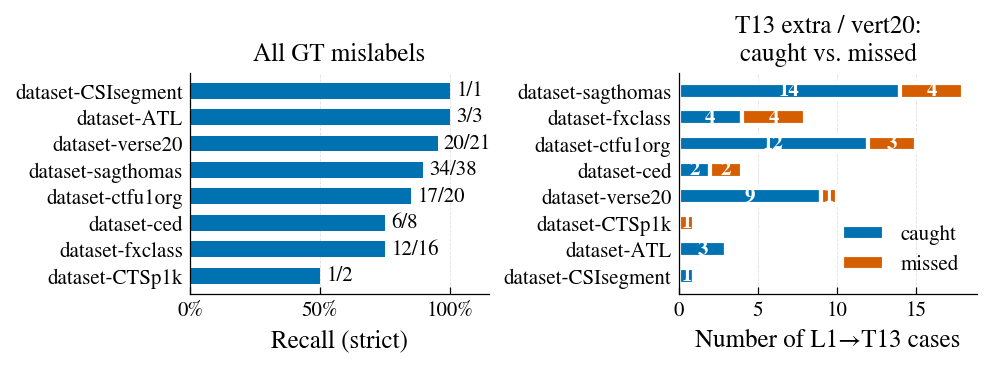

In [ ]:
# Recall per dataset (only datasets with GT mislabels) + where the missed L1→T13 cases come from
d = per_ds[per_ds["gt_mislabels"] > 0].sort_values("recall")
t13 = scores_df[(scores_df["anomaly_type"] == "T13_extra") & (scores_df["vert_id"] == 20)]
t13_ds = pd.crosstab(t13["dsname"], t13["flagged"]).reindex(columns=[True, False], fill_value=0)
t13_ds.columns = ["caught", "missed"]
t13_ds = t13_ds.sort_values(["missed", "caught"])

fig, (a1, a2) = plt.subplots(1, 2, figsize=plotstyle.figsize(1.0, 0.36))
bars = a1.barh(d.index, d["recall"], color=C_CLEAN, height=0.6)
a1.bar_label(bars, labels=[f"{f}/{n}" for f, n in zip(d["found"], d["gt_mislabels"])], padding=3, fontsize=10)
a1.set(xlim=(0, 1.15), xlabel="Recall (strict)", title="All GT mislabels")
a1.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
a1.grid(axis="y", visible=False)

left = np.zeros(len(t13_ds))
for col, color in [("caught", C_CLEAN), ("missed", C_MIS)]:
    b = a2.barh(t13_ds.index, t13_ds[col], left=left, color=color, height=0.6, label=col,
                edgecolor="white", linewidth=2)
    a2.bar_label(b, labels=[str(v) if v else "" for v in t13_ds[col]], label_type="center",
                 color="white", fontsize=10, fontweight="bold")
    left += t13_ds[col].values
a2.set(xlabel="Number of L1→T13 cases", title="T13 extra / vert20:\ncaught vs. missed")
a2.grid(axis="y", visible=False)
a2.legend(loc="lower right")
save(fig, "figA_4_per_dataset")
plt.show()


## Check: every figure was saved

In [ ]:
# ── Every thesis figure must have been (re)written to OUT_FIG_DIR by this run ─────────────────────
EXPECTED_FIGS = ['fig6_01_histogram_all_ep8_no_LO', 'fig6_02a_glare_glarex_recall_curve', 'fig6_02b_glare_glarex_f1_curve', 'fig6_03_histogram_T12missing_ep8_no_LO', 'fig6_04_histogram_T13extra_ep8_no_LO', 'fig6_05_histogram_LabelShift_ep8_no_LO', 'fig6_06_grad_norm_T12_missing', 'fig6_07_grad_norm_T13_extra', 'fig6_08_grad_norm_correct', 'fig6_09_recall_curves_by_n', 'fig6_10_f1_curves', 'fig6_11_recall_f1_curve_ep8_new', 'fig6_12_histogram_T12missing_ep8_new', 'fig6_13_histogram_T13extra_ep8_new', 'fig6_14_missed_T13_categories_bar', 'fig6_15_score0_categories_bar', 'fig6_16_T13_score8_comparison', 'fig6_17_confusion_suggested_all_gt_LO', 'fig6_18_recall_f1_vs_fraction_label_override_8ep_23092026_2135', 'figA_1_T13_grad_norm_curves_3groups', 'figA_2_rank_hist_t12missing_label_override_8ep_23092026_2135', 'figA_3_rank_hist_t13extra_label_override_8ep_23092026_2135', 'figA_4_per_dataset']

not_written = []
for name in EXPECTED_FIGS:
    p = OUT_FIG_DIR / f"{name}.pdf"
    ok = p.exists() and p.stat().st_mtime_ns != _FIGS_BEFORE.get(p.name)
    print(("ok       " if ok else "MISSING  ") + p.name)
    if not ok:
        not_written.append(p.name)
assert not not_written, f"not written by this run: {not_written}"
print(f"\nall {len(EXPECTED_FIGS)} figures saved to {OUT_FIG_DIR}")


ok       fig6_01_histogram_all_ep8_no_LO.pdf
ok       fig6_02a_glare_glarex_recall_curve.pdf
ok       fig6_02b_glare_glarex_f1_curve.pdf
ok       fig6_03_histogram_T12missing_ep8_no_LO.pdf
ok       fig6_04_histogram_T13extra_ep8_no_LO.pdf
ok       fig6_05_histogram_LabelShift_ep8_no_LO.pdf
ok       fig6_06_grad_norm_T12_missing.pdf
ok       fig6_07_grad_norm_T13_extra.pdf
ok       fig6_08_grad_norm_correct.pdf
ok       fig6_09_recall_curves_by_n.pdf
ok       fig6_10_f1_curves.pdf
ok       fig6_11_recall_f1_curve_ep8_new.pdf
ok       fig6_12_histogram_T12missing_ep8_new.pdf
ok       fig6_13_histogram_T13extra_ep8_new.pdf
ok       fig6_14_missed_T13_categories_bar.pdf
ok       fig6_15_score0_categories_bar.pdf
ok       fig6_16_T13_score8_comparison.pdf
ok       fig6_17_confusion_suggested_all_gt_LO.pdf
ok       fig6_18_recall_f1_vs_fraction_label_override_8ep_23092026_2135.pdf
ok       figA_1_T13_grad_norm_curves_3groups.pdf
ok       figA_2_rank_hist_t12missing_label_override_8ep_2309202